# <center>Team 7 — Code Avengers </center>
## Labs + Prescription Medication Analysis
### Descriptive Analysis and Prescriptive Analysis

- **Primary dataset 1: Labs** — 2,008 patient-level rows and a wide range of physiologic/laboratory variables.
- **Primary dataset 2: Patient Prescriptions** — medication exposure records with multiple drugs per patient.
- **Supporting dataset: Demography** — used only for meaningful segmentation such as **age category, gender, BMI, weight and height**.

> **Important:** Prescriptive analysis here means **what the analytics team should review or investigate next**.  
> It does **not** prescribe medications or provide clinical treatment recommendations.

# Import, File Loading and Merging

In [ ]:
# Optional one-time installation if your local Jupyter environment needs it:
# %pip install pandas numpy plotly scipy nbformat

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import spearmanr, mannwhitneyu


In [5]:
# Define the main project folder
project_folder = Path(
    r"C:\Users\swith\OneDrive\Desktop\Swithi\Numpy Ninja\Python Hackathon Sept 2026\Python_Hackathon_Sep_2026\cardiac_failure\__Final_Cleaned Dataset"
)

# Define CSV filenames
FILES = {
    "labs": "Team7_CodeAvengers_Category1_DataCleaning_labs.csv",
    "prescriptions": "Team7_CodeAvengers_Category1_DataCleaning_patient_precriptions.csv",
    "demography": "Team7_CodeAvengers_Category1_DataCleaning_demography.csv",
}

# Read the cleaned datasets
labs = pd.read_csv(project_folder / FILES["labs"])
prescriptions = pd.read_csv(project_folder / FILES["prescriptions"])
demography = pd.read_csv(project_folder / FILES["demography"])

# Verify successful loading
print("Labs:", labs.shape)
print("Prescriptions:", prescriptions.shape)
print("Demography:", demography.shape)

Labs: (2008, 107)
Prescriptions: (15362, 2)
Demography: (2008, 7)


In [14]:
# Validate patient-level uniqueness before merging.
for name, df in {"labs": labs, "demography": demography}.items():
    print("\t")
    print(
        f"{name:12s} rows={len(df):,} | "
        f"unique patients={df['inpatient_number'].nunique():,} | "
        f"duplicate patient IDs={df['inpatient_number'].duplicated().sum():,}"
    )
print("\t")
print(
    f"prescriptions rows={len(prescriptions):,} | "
    f"unique patients={prescriptions['inpatient_number'].nunique():,} | "
    f"unique drug names={prescriptions['drug_name'].nunique():,}"
)

# Clean drug-name whitespace only; do not change clinical content.
rx = prescriptions.copy()
rx["drug_name"] = rx["drug_name"].astype(str).str.strip()

# Aggregate prescriptions BEFORE patient-level merge to avoid multiplying lab rows.
rx_summary = (
    rx.groupby("inpatient_number")
      .agg(
          prescription_rows=("drug_name", "size"),
          unique_medication_count=("drug_name", "nunique")
      )
      .reset_index()
)

patient = (
    labs
    .merge(demography, on="inpatient_number", how="left", validate="one_to_one")
    .merge(rx_summary, on="inpatient_number", how="left", validate="one_to_one")
)

patient[["prescription_rows", "unique_medication_count"]] = (
    patient[["prescription_rows", "unique_medication_count"]].fillna(0)
)

AGE_ORDER = ["21-29", "29-39", "39-49", "49-59", "59-69", "69-79", "79-89", "89-110"]
AGE_MIDPOINT = {
    "21-29": 25, "29-39": 34, "39-49": 44, "49-59": 54,
    "59-69": 64, "69-79": 74, "79-89": 84, "89-110": 99.5
}

patient["agecat"] = pd.Categorical(patient["agecat"], categories=AGE_ORDER, ordered=True)
patient["age_midpoint"] = patient["agecat"].astype(str).map(AGE_MIDPOINT)

print("\n Final patient-level analytical dataset:", patient.shape)
print("\n Unique patients:", patient["inpatient_number"].nunique())

	
labs         rows=2,008 | unique patients=2,008 | duplicate patient IDs=0
	
demography   rows=2,008 | unique patients=2,008 | duplicate patient IDs=0
	
prescriptions rows=15,362 | unique patients=2,007 | unique drug names=25

 Final patient-level analytical dataset: (2008, 116)

 Unique patients: 2008


In [15]:
# Helper functions reused throughout the notebook.

def p_text(p):
    if pd.isna(p):
        return "NA"
    if p < 0.001:
        return "< 0.001"
    return f"= {p:.3f}"

def safe_spearman(df, x, y):
    tmp = df[[x, y]].dropna()
    if len(tmp) < 3:
        return np.nan, np.nan, len(tmp)
    rho, p = spearmanr(tmp[x], tmp[y])
    return rho, p, len(tmp)

def med_usage_by_group(group_col, drugs):
    unique_rx = (
        rx.drop_duplicates(["inpatient_number", "drug_name"])
          .merge(patient[["inpatient_number", group_col]], on="inpatient_number", how="left")
    )
    numerator = (
        unique_rx[unique_rx["drug_name"].isin(drugs)]
        .groupby([group_col, "drug_name"], observed=True)["inpatient_number"]
        .nunique()
        .unstack(fill_value=0)
    )
    denominator = patient.groupby(group_col, observed=True)["inpatient_number"].nunique()
    return numerator.div(denominator, axis=0) * 100

def standardized_mean_difference(df, group_col, value_col):
    a = df.loc[df[group_col], value_col].dropna()
    b = df.loc[~df[group_col], value_col].dropna()
    if len(a) < 2 or len(b) < 2:
        return np.nan
    pooled = np.sqrt(
        ((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1))
        / (len(a)+len(b)-2)
    )
    return (a.mean()-b.mean())/pooled if pooled else np.nan

# <center> PART A — DESCRIPTIVE ANALYSIS </center> 

The objective is to **describe and explain the observed patterns** in the cleaned Labs and Prescription datasets.

Demography is used only when it helps answer a meaningful subgroup question.

### DA1. How is the patient distributed across age categories and gender?
**Analysis type:** Descriptive — Demographic context

**Reasoning**  

Before comparing laboratory or medication patterns, we need to know which demographic groups dominate the sample and which groups are too small for stable conclusions.


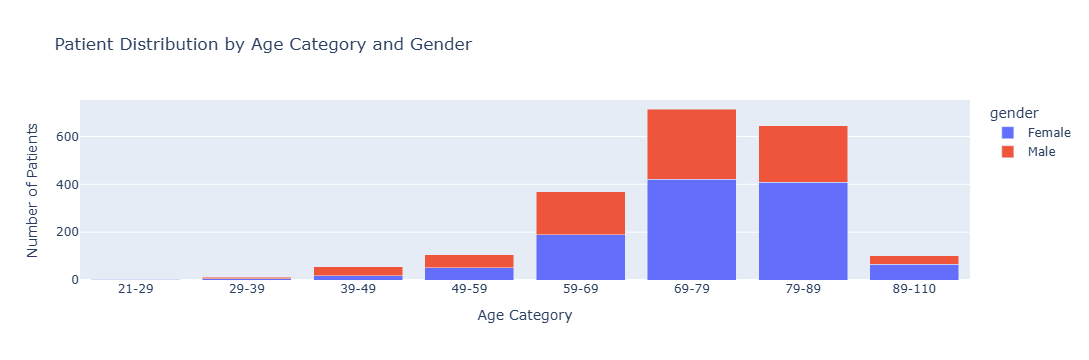

Age distribution (%)


,percent
agecat,
21-29,0.200
29-39,0.600
39-49,2.800
49-59,5.300
59-69,18.300
69-79,35.600
79-89,32.200
89-110,5.000


Gender distribution (%)


,percent
gender,
Female,57.900
Male,42.100


In [16]:
cohort = (
    patient.groupby(["agecat", "gender"], observed=True)
           .size()
           .reset_index(name="patients")
)
fig = px.bar(
    cohort, x="agecat", y="patients", color="gender",
    barmode="stack",
    title="Patient Distribution by Age Category and Gender",
    labels={"agecat":"Age Category", "patients":"Number of Patients"}
)
fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)
fig.show()

age_pct = patient["agecat"].value_counts(sort=False, normalize=True).mul(100).round(1)
gender_pct = patient["gender"].value_counts(normalize=True).mul(100).round(1)

print("Age distribution (%)")
display(age_pct.rename("percent").to_frame())
print("Gender distribution (%)")
display(gender_pct.rename("percent").to_frame())

**Actual Insight**  

The cohort is concentrated in the older age categories, so overall lab and medication summaries are influenced strongly by older adults. Small age groups should be interpreted cautiously even when their averages look very different.

### DA2. Which laboratory variables have the highest missing values?
**Analysis type:** Descriptive — Data quality

**Reasoning**  

A wide laboratory table can contain very different sample sizes from one variable to another. missing values must be quantified before comparing or correlating variables so that measurements are not treated as if they represent all patients.


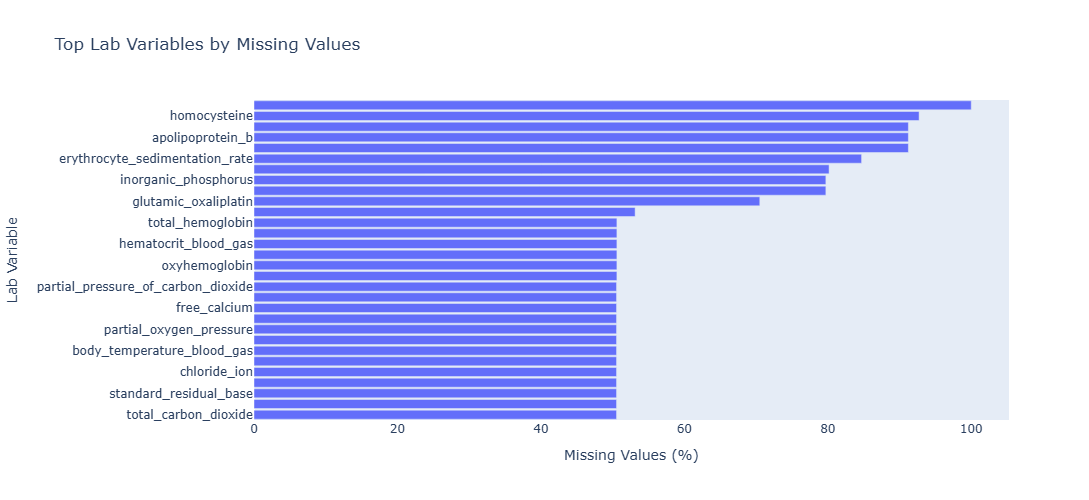

In [41]:
lab_missing_values = (
    labs.drop(columns=["inpatient_number"])
        .isna()
        .mean()
        .mul(100)
        .sort_values(ascending=False)
)

plot = lab_missing_values.head(30).sort_values()

fig = px.bar(
    x=plot.values,
    y=plot.index,
    orientation="h",
    title="Top Lab Variables by Missing Values",
    labels={"x": "Missing Values (%)", "y": "Lab Variable"}
)

fig.update_layout(
    height=500,
    bargap=0.15,
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=False)
)

fig.show()

**Actual Insight**  
Missing values vary across lab tests. Tests with many missing values may still be useful for specific analyses, while tests with more complete data are better suited for overall comparisons and dashboards. Each analysis should clearly show how many patients or records were included.

### DA3. What are the typical values and ranges of the key laboratory tests?
**Analysis type:** Descriptive — Lab profile

**Reasoning**  
A compact summary table gives a baseline view of typical values, spread, skew and sample availability before any subgroup analysis.

In [24]:
key_labs = [
    "pulse", "systolic_blood_pressure", "diastolic_blood_pressure",
    "creatinine_enzymatic_method", "urea", "uric_acid",
    "glomerular_filtration_rate", "white_blood_cell",
    "hemoglobin", "platelet", "high_sensitivity_troponin",
    "brain_natriuretic_peptide", "albumin",
    "glucose_blood_gas", "lactate", "oxygen_saturation"
]

summary = patient[key_labs].describe().T
summary["missing_pct"] = patient[key_labs].isna().mean().mul(100)
display(
    summary[["count","mean","std","min","25%","50%","75%","max","missing_pct"]]
    .round(3)
)

,count,mean,std,min,25%,50%,75%,max,missing_pct
pulse,"2,008.000",85.235,21.539,0.000,70.000,82.000,98.000,198.000,0.000
systolic_blood_pressure,"2,008.000",131.057,24.742,0.000,113.000,130.000,146.250,252.000,0.000
diastolic_blood_pressure,"2,008.000",76.573,14.461,0.000,65.000,76.000,85.000,146.000,0.000
creatinine_enzymatic_method,"1,985.000",108.916,79.122,27.600,64.900,87.100,122.700,963.400,1.145
urea,"1,985.000",9.565,5.546,1.580,5.900,8.030,11.540,45.630,1.145
uric_acid,"1,985.000",483.019,169.655,62.000,361.000,458.000,572.000,"1,409.000",1.145
glomerular_filtration_rate,"1,945.000",68.664,36.612,3.130,41.600,64.790,90.120,281.010,3.137
white_blood_cell,"1,981.000",7.308,3.474,1.660,5.070,6.500,8.670,32.790,1.345
hemoglobin,"1,980.000",115.069,24.532,29.000,101.000,117.000,131.000,200.000,1.394
platelet,"1,981.000",145.148,64.923,5.000,101.000,135.000,177.000,646.000,1.345


**Actual Insight**  

The summary shows why median and interquartile range are often preferable to means for variables such as BNP and troponin. It also makes missing values visible beside the distribution itself.

### DA4. How does blood-gas glucose vary across age categories?
**Analysis type:** Descriptive — Lab × age

**Reasoning**  

Analyzing glucose levels by age group helps us understand whether glucose levels change with age. A box plot helps show how glucose levels vary within each age group and highlights unusually high or low values.


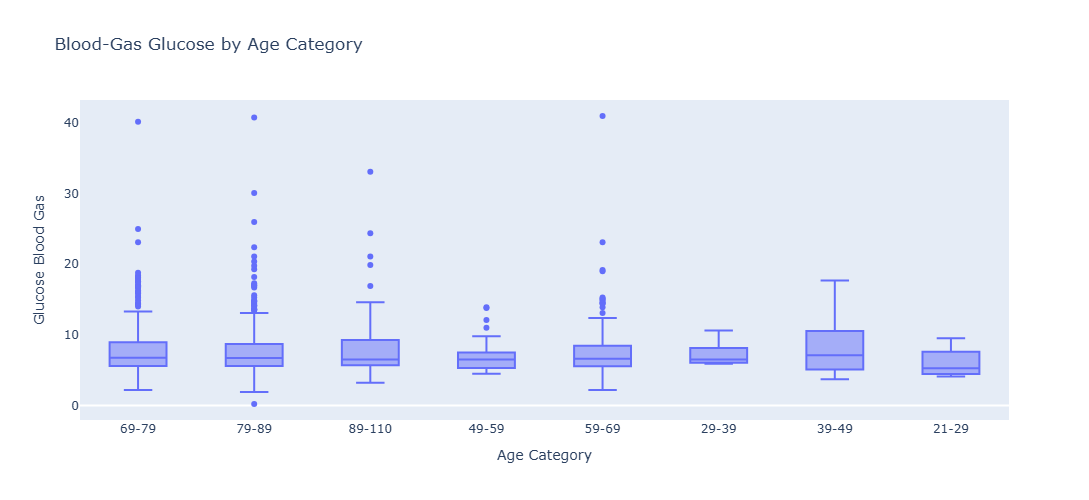

,count,mean,median
agecat,,,
21-29,4,6.020,5.250
29-39,5,7.280,6.500
39-49,21,8.290,7.100
49-59,42,6.920,6.500
59-69,168,7.650,6.600
69-79,344,7.900,6.750
79-89,350,7.850,6.700
89-110,59,8.440,6.500


In [42]:
tmp = patient[["agecat","glucose_blood_gas"]].dropna()
fig = px.box(
    tmp, x="agecat", y="glucose_blood_gas", points="outliers",
    title="Blood-Gas Glucose by Age Category",
    labels={"agecat":"Age Category", "glucose_blood_gas":"Glucose Blood Gas"}
)
fig.update_layout(
    height=500,
    bargap=0.15,
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=False)
)
fig.show()

display(
    tmp.groupby("agecat", observed=True)["glucose_blood_gas"]
       .agg(["count","mean","median"])
       .round(2)
)

**Actual Insight**  
Glucose levels vary across all age groups, with no clear pattern based on age. This suggests that age alone does not explain differences in glucose levels, and other factors may also play a role.

### DA5: How do average eGFR levels differ across age groups and genders, and what demographic patterns emerge in renal function? 
**Analysis type:** Descriptive — Lab × age

**Reasoning**  

Comparing eGFR levels across age groups and genders helps us understand how kidney function measurements differ among patients. A line chart makes it easier to identify changes in average eGFR levels across age categories and compare patterns between males and females.


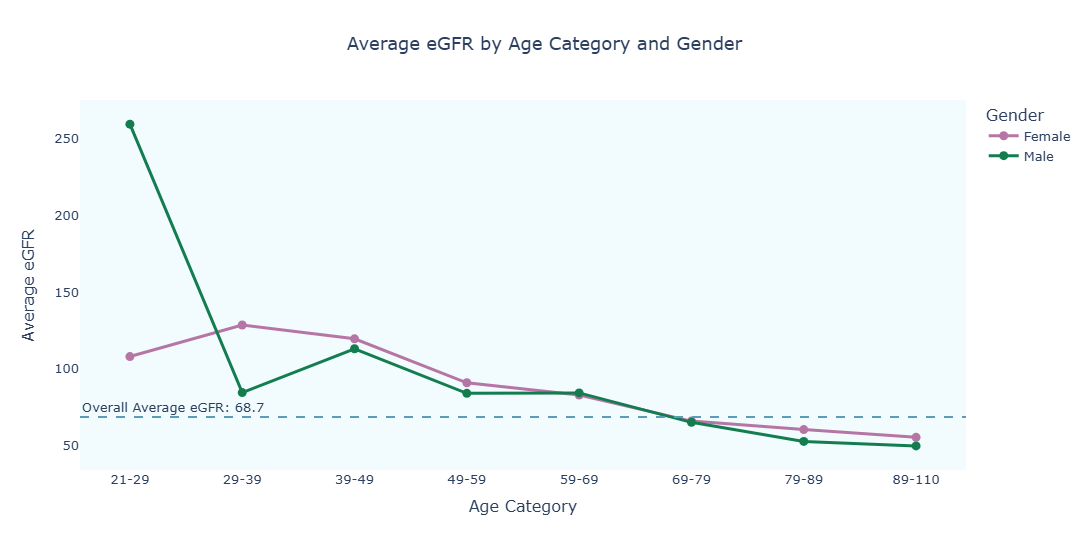

,Age Category,Gender,Average eGFR,Records
0,21-29,Female,108.060,3
1,21-29,Male,259.510,1
2,29-39,Female,128.590,5
3,29-39,Male,84.580,7
4,39-49,Female,119.610,17
5,39-49,Male,113.150,37
6,49-59,Female,90.960,49
7,49-59,Male,84.110,55
8,59-69,Female,82.980,182
9,59-69,Male,84.370,172


In [43]:
# Prepare data
tmp = patient[
    ["agecat", "gender", "glomerular_filtration_rate"]
].dropna()

# Calculate average eGFR by age category and gender
egfr_by_group = (
    tmp.groupby(["agecat", "gender"], observed=True)["glomerular_filtration_rate"]
       .agg(["mean", "count"])
       .reset_index()
)

# Create line chart
fig = px.line(
    egfr_by_group,
    x="agecat",
    y="mean",
    color="gender",
    markers=True,
    title="Average eGFR by Age Category and Gender",
    labels={
        "agecat": "Age Category",
        "mean": "Average eGFR",
        "gender": "Gender"
    },
    color_discrete_sequence=["#B576A5", "#147D50"],
    hover_data=["count"]
)

# Customize lines and markers
fig.update_traces(
    line=dict(width=3),
    marker=dict(size=9)
)

# Add overall average reference line
overall_avg = tmp["glomerular_filtration_rate"].mean()

fig.add_hline(
    y=overall_avg,
    line_dash="dash",
    line_color="#5B9DB8",
    annotation_text=f"Overall Average eGFR: {overall_avg:.1f}",
    annotation_position="top left"
)

# Customize chart appearance
fig.update_layout(
    height=550,
    plot_bgcolor="#F2FBFD",
    paper_bgcolor="white",
    title_x=0.5,
    xaxis_title="Age Category",
    yaxis_title="Average eGFR",
    legend_title="Gender",
    font=dict(size=13),
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=False)
)

fig.show()

# Display summary table
display(
    egfr_by_group
    .rename(columns={
        "agecat": "Age Category",
        "gender": "Gender",
        "mean": "Average eGFR",
        "count": "Records"
    })
    .round(2)
)

**Actual Insight**  
Average eGFR levels generally decrease as age increases, suggesting that kidney function tends to be lower in older patients. Males and females show a similar pattern after age 39, with eGFR levels falling below the overall average in the older age groups. The unusually high value for males aged 21–29 may be due to a small number of records and should be checked before drawing conclusions.

### DA6. What is the relationship between creatinine and eGFR?
**Analysis type:** Descriptive / Diagnostic — Lab-to-lab

**Reasoning**  

Creatinine and eGFR are related kidney-function measures. A scatter plot plus Spearman correlation tests whether they move together monotonically without assuming a linear relationship.

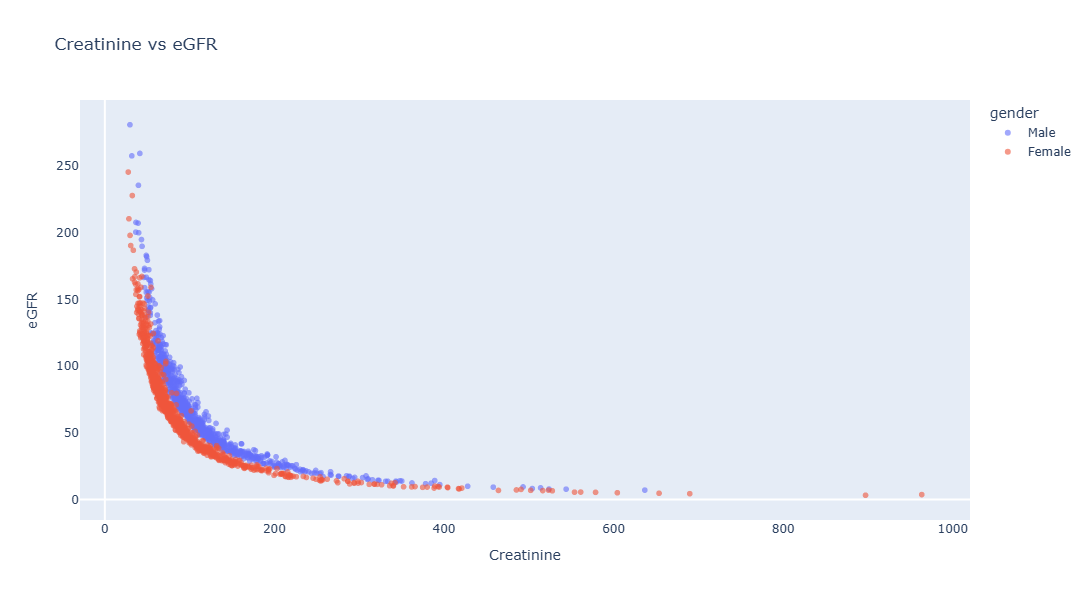

Spearman rho=-0.944, p < 0.001, n=1,945


In [44]:
tmp = patient[[
    "creatinine_enzymatic_method","glomerular_filtration_rate",
    "agecat","gender"
]].dropna()

fig = px.scatter(
    tmp,
    x="creatinine_enzymatic_method",
    y="glomerular_filtration_rate",
    color="gender",
    hover_data=["agecat"],
    opacity=0.6,
    title="Creatinine vs eGFR",
    labels={
        "creatinine_enzymatic_method":"Creatinine",
        "glomerular_filtration_rate":"eGFR"
    }
)
fig.update_layout(
    height=600,
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=False)
)
fig.show()

rho,p,n = safe_spearman(tmp, "creatinine_enzymatic_method", "glomerular_filtration_rate")
print(f"Spearman rho={rho:.3f}, p {p_text(p)}, n={n:,}")

**Actual Insight**  
This chart shows a clear relationship between creatinine and eGFR. As creatinine levels increase, eGFR levels decrease. This shows how closely these two kidney-related lab measurements are connected.

### DA7. What is the relationship between urea and eGFR?
**Analysis type:** Descriptive / Diagnostic — Lab-to-lab

**Reasoning**  

Urea provides another kidney-related marker. Comparing it with eGFR tests whether the broader renal profile shows a consistent pattern beyond creatinine alone.


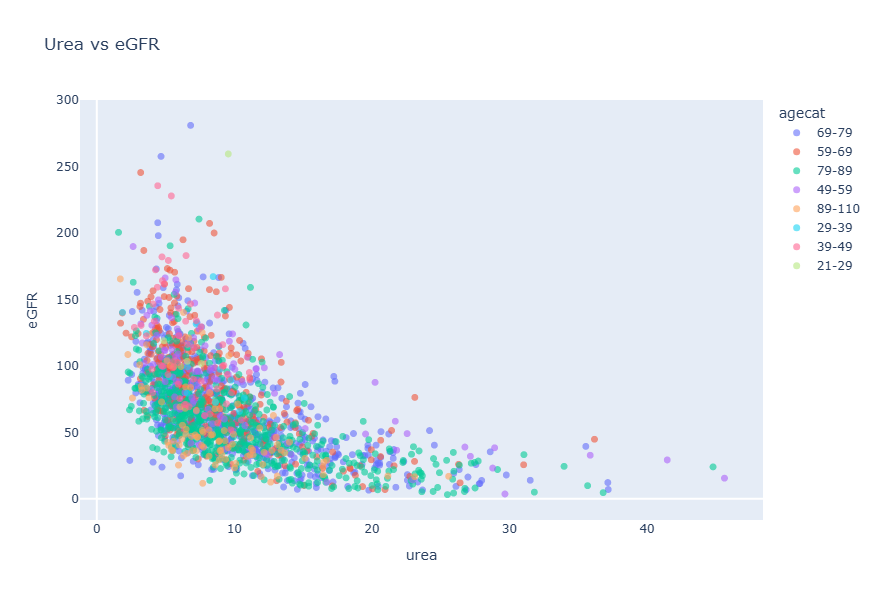

Spearman rho=-0.669, p < 0.001, n=1,945


In [48]:
tmp = patient[["urea","glomerular_filtration_rate","agecat"]].dropna()
fig = px.scatter(
    tmp, x="urea", y="glomerular_filtration_rate",
    color="agecat", opacity=0.6,
    title="Urea vs eGFR",
    labels={"glomerular_filtration_rate":"eGFR"}
)
fig.update_layout(
    height=600,
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=False)
)
fig.update_traces(
    marker=dict(
        symbol="circle",
        size=7
    )
)
fig.show()
rho,p,n = safe_spearman(tmp, "urea", "glomerular_filtration_rate")
print(f"Spearman rho={rho:.3f}, p {p_text(p)}, n={n:,}")

**Actual Insight**  

The renal markers form a consistent pattern: higher urea tends to occur with lower eGFR. This provides a more meaningful renal-function story than presenting each laboratory value independently.

## DA8: How does the utilization of the most commonly prescribed medications differ across age groups, and what age-related medication-use patterns can be identified? 

## Analysis type: Descriptive — Prescription × age heat map

* Reasoning

A heat map can compare several medications and age categories simultaneously. Percent prevalence is used instead of raw counts so age groups with different sizes can be compared fairly.

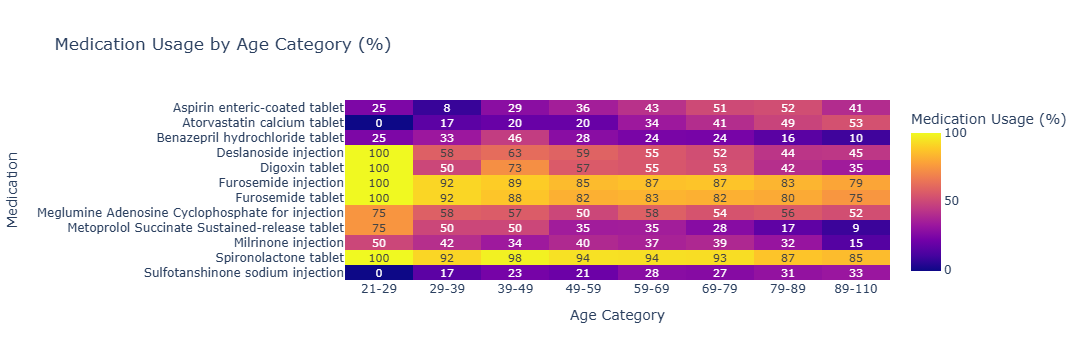

drug_name,Aspirin enteric-coated tablet,Atorvastatin calcium tablet,Benazepril hydrochloride tablet,Deslanoside injection,Digoxin tablet,Furosemide injection,Furosemide tablet,Meglumine Adenosine Cyclophosphate for injection,Metoprolol Succinate Sustained-release tablet,Milrinone injection,Spironolactone tablet,Sulfotanshinone sodium injection
agecat,,,,,,,,,,,,
21-29,25.000,0.000,25.000,100.000,100.000,100.000,100.000,75.000,75.000,50.000,100.000,0.000
29-39,8.300,16.700,33.300,58.300,50.000,91.700,91.700,58.300,50.000,41.700,91.700,16.700
39-49,28.600,19.600,46.400,62.500,73.200,89.300,87.500,57.100,50.000,33.900,98.200,23.200
49-59,35.800,19.800,28.300,59.400,56.600,84.900,82.100,50.000,34.900,39.600,94.300,20.800
59-69,42.700,33.700,24.200,55.400,55.200,86.700,83.200,58.400,35.300,37.200,93.800,28.300
69-79,51.200,41.100,23.600,52.300,53.100,87.400,82.200,54.100,27.700,39.300,93.300,27.400
79-89,52.300,48.900,16.300,43.800,41.600,83.400,80.500,56.300,17.300,31.900,87.500,31.000
89-110,40.600,53.500,9.900,44.600,34.700,79.200,75.200,52.500,8.900,14.900,85.100,32.700


In [143]:
# ---------------------------------------------------------
# DA8: Medication Utilization by Age Category
# ---------------------------------------------------------

# Keep patient age-category information
patient_data = (
    patient[["inpatient_number", "agecat"]]
    .dropna()
    .drop_duplicates()
)

# Keep prescription information
rx_data = (
    rx[["inpatient_number", "drug_name"]]
    .dropna()
    .drop_duplicates()
)

# Merge age category with medication information
med_data = patient_data.merge(
    rx_data,
    on="inpatient_number",
    how="inner"
)

# ---------------------------------------------------------
# Identify the 12 most commonly used medications
# ---------------------------------------------------------

drug_prev = (
    med_data.groupby("drug_name")["inpatient_number"]
    .nunique()
    .sort_values(ascending=False)
)

top_drugs = drug_prev.head(12).index.tolist()


# ---------------------------------------------------------
# Count number of patients in each age category
# ---------------------------------------------------------

age_counts = (
    patient_data.groupby("agecat")["inpatient_number"]
    .nunique()
)


# ---------------------------------------------------------
# Calculate medication use by age category
# ---------------------------------------------------------

med_counts = (
    med_data[med_data["drug_name"].isin(top_drugs)]
    .groupby(["agecat", "drug_name"])["inpatient_number"]
    .nunique()
    .unstack(fill_value=0)
)


# Convert counts to prevalence percentage within each age group
age_med = (
    med_counts
    .div(age_counts, axis=0)
    .mul(100)
)


# Keep your predefined clinical age-category order
age_med = age_med.reindex(AGE_ORDER)


# ---------------------------------------------------------
# Heatmap
# ---------------------------------------------------------

fig = px.imshow(
    age_med.T,
    aspect="auto",
    text_auto=".0f",
    title="Medication Usage by Age Category (%)",
    labels={
        "x": "Age Category",
        "y": "Medication",
        "color": "Medication Usage (%)"
    }
)

fig.show()


# Display calculated prevalence values
display(age_med.round(1))

## Actual Insight: 
Medication utilization differs across age groups, with certain commonly prescribed drugs showing greater usage in specific age categories. These patterns may reflect age-related differences in chronic disease burden and treatment requirements and can help identify patient groups where medication use may require closer clinical review.

# <center> PART B — PRESCRIPTIVE ANALYSIS </center>

In [54]:
ID, AGE, SEX = "inpatient_number", "agecat", "gender"
MIN_GROUP_N, MIN_PAIR_N = 10, 30
BG, FEMALE, MALE, TEAL = "#F2FBFD", "#B576A5", "#147D50", "#147D50"

for frame_name, frame, columns in [
    ("patient", patient, [ID, AGE, SEX]),
    ("labs", labs, [ID]),
]:
    absent = [c for c in columns if c not in frame.columns]
    if absent:
        raise KeyError(f"{frame_name} missing columns: {absent}")

# Use column names from the real labs CSV, not made-up marker names.
exclude_words = ("date", "time", "flag", "status", "label", "duration", "length", "index")
lab_candidates = []
for col in labs.columns:
    if col == ID or col not in patient.columns or any(w in col.lower() for w in exclude_words):
        continue
    numeric_values = pd.to_numeric(patient[col], errors="coerce")
    if numeric_values.notna().sum() >= 5 and numeric_values.nunique() >= 5:
        lab_candidates.append(col)

preferred_words = [
    "hemoglobin", "albumin", "troponin", "bnp", "natriuretic",
    "creatinine_enzymatic_method", "glomerular_filtration_rate",
    "urea", "glucose_blood_gas",
]
# Prioritize kidney-related laboratory biomarkers
kidney_markers = [
    "glomerular_filtration_rate",
    "creatinine_enzymatic_method",
    "urea"
]

# Identify other important laboratory biomarkers
preferred_words = [
    "hemoglobin",
    "albumin",
    "troponin",
    "bnp",
    "natriuretic",
    "glucose_blood_gas"
]

# Add available kidney markers first
MARKERS = [
    col for col in kidney_markers
    if col in lab_candidates
]

# Add other important biomarkers
for word in preferred_words:
    for col in lab_candidates:
        if word in col.lower() and col not in MARKERS:
            MARKERS.append(col)

# Add remaining laboratory biomarkers
MARKERS += [
    col for col in lab_candidates
    if col not in MARKERS
]

# Select the first 10 biomarkers
MARKERS = MARKERS[:10]

print("Selected Laboratory Biomarkers:")
print(MARKERS)
# One record per inpatient_number for analyses involving patient groups.
cols = [ID, AGE, SEX] + MARKERS
df = patient[cols].copy().dropna(subset=[ID])
for col in MARKERS:
    df[col] = pd.to_numeric(df[col], errors="coerce")
for col in [AGE, SEX]:
    df[col] = df[col].astype("string").str.strip().replace("", pd.NA)

raw_rows = len(df)
df = df.groupby(ID, as_index=False).agg({
    AGE: "first", SEX: "first", **{col: "median" for col in MARKERS}
})
print(f"Rows in merged patient data: {raw_rows:,}; distinct inpatient records: {len(df):,}")
if raw_rows > len(df):
    print("Repeated inpatient rows were combined using the median for each numeric lab.")

# Dataset-based comparison bounds: NOT clinical reference ranges.
BOUNDS = {
    col: (df[col].quantile(0.10), df[col].quantile(0.90))
    for col in MARKERS
}
flags = pd.DataFrame(index=df.index)
for col in MARKERS:
    low, high = BOUNDS[col]
    flags[col] = np.where(
        df[col].notna(),
        (df[col] < low) | (df[col] > high),
        np.nan
    ).astype(float)

print("Comparison method: below the 10th OR above the 90th cohort percentile.")

def style(fig, height=580):
    fig.update_layout(
        height=height, paper_bgcolor="white", plot_bgcolor=BG,
        font=dict(size=12), title_x=0.5
    )
    return fig

def group_text(row):
    return f"{row[AGE]} / {row[SEX]}"

Selected Laboratory Biomarkers:
['glomerular_filtration_rate', 'creatinine_enzymatic_method', 'urea', 'mean_hemoglobin_volume', 'mean_hemoglobin_concentration', 'hemoglobin', 'methemoglobin', 'reduced_hemoglobin', 'carboxyhemoglobin', 'oxyhemoglobin']
Rows in merged patient data: 2,008; distinct inpatient records: 2,008
Comparison method: below the 10th OR above the 90th cohort percentile.


# PA1. Which age and gender groups have more unusual kidney-related laboratory results?
* Reasoning: * Looking at eGFR, creatinine, and urea together gives more context than checking one marker at a time. The radar shows the percentage of complete records in each group with low eGFR or high creatinine/urea relative to this dataset. Groups with few records are not displayed.


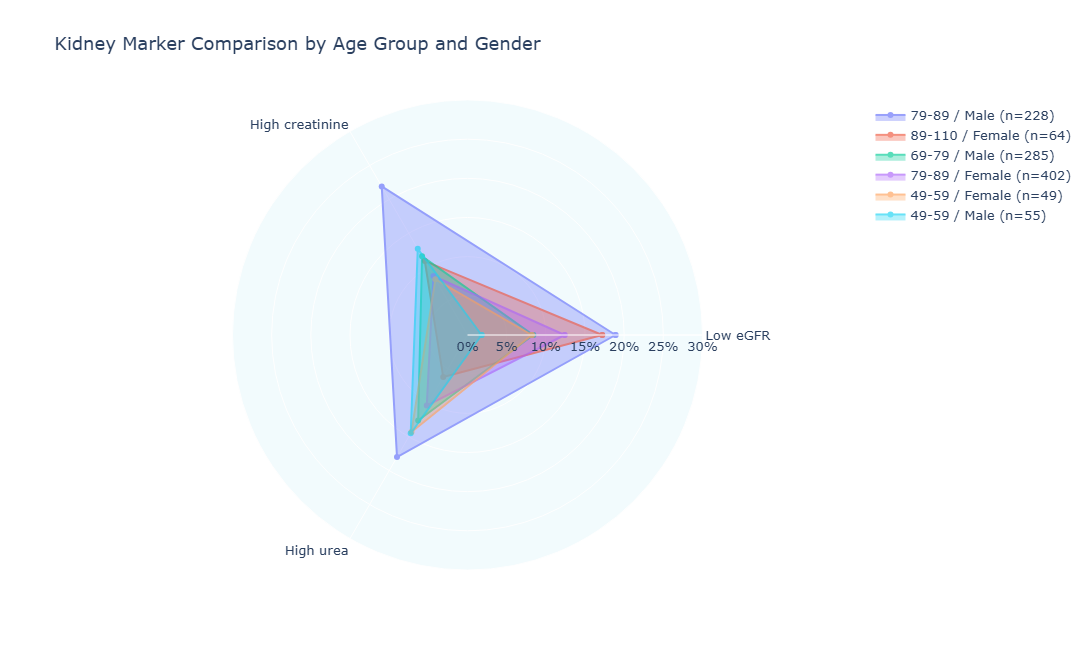

,agecat,gender,records,low_egfr,high_creatinine,high_urea,average_flags
13,79-89,Male,228,0.189,0.219,0.180,0.588
14,89-110,Female,64,0.172,0.109,0.062,0.344
11,69-79,Male,285,0.084,0.116,0.126,0.326
12,79-89,Female,402,0.124,0.087,0.104,0.316
6,49-59,Female,49,0.082,0.082,0.143,0.306
7,49-59,Male,55,0.018,0.127,0.145,0.291
10,69-79,Female,403,0.104,0.092,0.089,0.285
8,59-69,Female,182,0.088,0.077,0.088,0.253
15,89-110,Male,35,0.057,0.057,0.000,0.114
9,59-69,Male,172,0.012,0.052,0.041,0.105


Actual Insight: Among groups with at least 10 complete records, 79-89 / Male has the largest average count of these three dataset-based kidney flags (0.59 out of 3, n=228). Review this group's underlying measurements; these percentile flags are not diagnoses.


In [83]:
EGFR = "glomerular_filtration_rate"
CREAT = "creatinine_enzymatic_method"
UREA = "urea"
required = [EGFR, CREAT, UREA]
missing = [c for c in required if c not in df.columns]
if missing:
    print("PA1 skipped. Kidney markers missing:", missing)
else:
    kidney = df[[ID, AGE, SEX] + required].dropna().copy()
    kidney = kidney.dropna(subset=[AGE, SEX])
    kidney["Low eGFR"] = (kidney[EGFR] <= df[EGFR].quantile(.10)).astype(int)
    kidney["High creatinine"] = (kidney[CREAT] >= df[CREAT].quantile(.90)).astype(int)
    kidney["High urea"] = (kidney[UREA] >= df[UREA].quantile(.90)).astype(int)
    kidney["kidney_flags"] = kidney[["Low eGFR", "High creatinine", "High urea"]].sum(axis=1)
    summary1 = kidney.groupby([AGE, SEX], observed=True).agg(
        records=(ID, "size"),
        low_egfr=("Low eGFR", "mean"),
        high_creatinine=("High creatinine", "mean"),
        high_urea=("High urea", "mean"),
        average_flags=("kidney_flags", "mean")
    ).reset_index()
    summary1 = summary1[summary1.records >= MIN_GROUP_N].sort_values("average_flags", ascending=False)
    if summary1.empty:
        print(f"PA1: No age/gender group has {MIN_GROUP_N} complete kidney records.")
    else:
        axis_labels = ["Low eGFR", "High creatinine", "High urea"]
        cols = ["low_egfr", "high_creatinine", "high_urea"]
        fig = go.Figure()
        for _, row in summary1.head(6).iterrows():
            values = [round(float(row[c]) * 100, 1) for c in cols]
            fig.add_trace(go.Scatterpolar(
                r=values + [values[0]], theta=axis_labels + [axis_labels[0]],
                fill="toself", name=f"{group_text(row)} (n={int(row.records)})",
                opacity=.65
            ))
        
        fig.update_layout(
            title="Kidney Marker Comparison by Age Group and Gender",
            polar=dict(
                radialaxis=dict(
                visible=True,
                range=[0, 30],
                dtick=5,
                ticksuffix="%"),
            bgcolor="#F2FBFD"
        ),
        height=650,
        paper_bgcolor="white",
        font=dict(size=13),
        xaxis=dict(showgrid=False),
        yaxis=dict(showgrid=False)
)
    
        fig.show()
        display(summary1.round(3))
        top = summary1.iloc[0]
        print("Actual Insight:", f"Among groups with at least {MIN_GROUP_N} complete records, "
              f"{group_text(top)} has the largest average count of these three dataset-based kidney flags "
              f"({top.average_flags:.2f} out of 3, n={int(top.records)}). "
              "Review this group's underlying measurements; these percentile flags are not diagnoses.")

# PA2. Which age groups have more patients with lower or higher laboratory measurements?
* Reasoning:* Comparing hemoglobin, albumin, and glucose levels across age groups helps us understand which patients have lower or higher laboratory measurements. A Treemap makes it easier to see how these results are distributed across different age groups and identify groups that may need further review

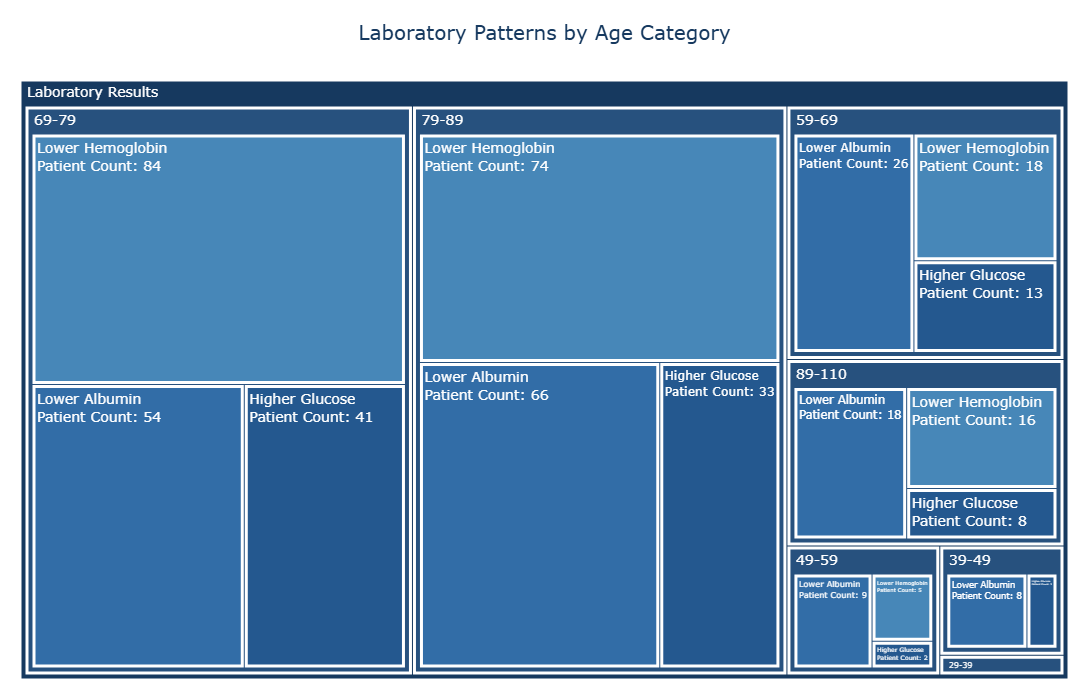

In [84]:
import pandas as pd
import plotly.graph_objects as go

# --------------------------------------------------
# 1. Select laboratory measurements
# --------------------------------------------------

lab_options = {
    "Lower Hemoglobin": (
        ["hemoglobin", "hemoglobin_blood_gas"],
        "low"
    ),

    "Lower Albumin": (
        ["albumin", "albumin_serum"],
        "low"
    ),

    "Higher Glucose": (
        ["glucose_blood_gas", "glucose"],
        "high"
    ),

    "Higher Troponin": (
        ["troponin_i", "troponin_t", "troponin"],
        "high"
    )
}

selected_labs = {}

for label, (options, direction) in lab_options.items():

    col = next(
        (c for c in options if c in patient.columns),
        None
    )

    if col:
        selected_labs[label] = (col, direction)

if not selected_labs:
    raise ValueError("No laboratory measurements found.")


# --------------------------------------------------
# 2. Calculate patient counts
# --------------------------------------------------

results = []

for label, (col, direction) in selected_labs.items():

    tmp = patient[
        ["inpatient_number", "agecat", col]
    ].copy()

    tmp[col] = pd.to_numeric(
        tmp[col],
        errors="coerce"
    )

    tmp = tmp.dropna()

    if tmp.empty:
        continue

    # Count each inpatient number once for each lab test
    tmp = (
        tmp.groupby(
            ["inpatient_number", "agecat"],
            observed=True,
            as_index=False
        )[col]
        .median()
    )

    # Identify lower or higher measurements
    if direction == "low":

        limit = tmp[col].quantile(0.10)

        tmp["selected_result"] = tmp[col] < limit

    else:

        limit = tmp[col].quantile(0.90)

        tmp["selected_result"] = tmp[col] > limit

    # Calculate patient counts by age category
    summary = (
        tmp.groupby(
            "agecat",
            observed=True
        )["selected_result"]
        .agg(
            patients_tested="count",
            patient_count="sum"
        )
        .reset_index()
    )

    summary["Lab Result"] = label

    summary["Patient Percentage"] = (
        summary["patient_count"]
        / summary["patients_tested"]
        * 100
    )

    results.append(summary)


# --------------------------------------------------
# 3. Combine laboratory results
# --------------------------------------------------

if not results:
    raise ValueError("No laboratory results are available.")

lab_summary = pd.concat(
    results,
    ignore_index=True
)

lab_summary = lab_summary.rename(
    columns={
        "agecat": "Age Category"
    }
)

lab_summary["Age Category"] = (
    lab_summary["Age Category"].astype(str)
)

# Keep groups with at least 10 tested patients
plot_data = lab_summary[
    (lab_summary["patients_tested"] >= 10) &
    (lab_summary["patient_count"] > 0)
].copy()

if plot_data.empty:
    raise ValueError("No results available for the Treemap.")


# --------------------------------------------------
# 4. Define blue color palette
# --------------------------------------------------

lab_colors = {
    "Lower Hemoglobin": "#4787B8",
    "Lower Albumin": "#326DA7",
    "Higher Glucose": "#24588F",
    "Higher Troponin": "#123F70"
}


# --------------------------------------------------
# 5. Create Treemap hierarchy
# --------------------------------------------------

nodes = []

# Main category
nodes.append({
    "id": "root",
    "label": "Laboratory Results",
    "parent": "",
    "value": int(plot_data["patient_count"].sum()),
    "color": "#16395F",

    "text": "Laboratory Results",

    "hover": (
        "<b>Laboratory Results</b><br>"
        "Select an age group to view laboratory results."
    )
})


# Age categories
for age, age_data in plot_data.groupby(
    "Age Category",
    sort=False
):

    age_id = f"age_{age}"

    age_count = int(
        age_data["patient_count"].sum()
    )

    nodes.append({
        "id": age_id,
        "label": age,
        "parent": "root",
        "value": age_count,
        "color": "#27517E",

        "text": f"Age: {age}",

        "hover": (
            f"<b>Age Group: {age}</b><br>"
            "Select a laboratory measurement for details."
        )
    })

    # IMPORTANT:
    # Laboratory boxes must be inside the age-group loop.

    for _, row in age_data.iterrows():

        lab_name = row["Lab Result"]

        count = int(row["patient_count"])

        tested = int(row["patients_tested"])

        percentage = float(row["Patient Percentage"])

        nodes.append({
            "id": f"{age_id}_{lab_name}",
            "label": lab_name,
            "parent": age_id,
            "value": count,
            "color": lab_colors[lab_name],

            "text": (
                f"{lab_name}<br>"
                f"Patient Count: {count}"
            ),

            "hover": (
                f"<b>{lab_name}</b><br>"
                f"Age Group: {age}<br>"
                f"Patient Count: {count:,}<br>"
                f"Tested Patients: {tested:,}<br>"
                f"Patient Percentage: {percentage:.1f}%"
            )
        })


# --------------------------------------------------
# 6. Create Treemap
# --------------------------------------------------

fig = go.Figure(

    go.Treemap(
        ids=[
            n["id"]
            for n in nodes
        ],
        labels=[
            n["label"]
            for n in nodes
        ],
        parents=[
            n["parent"]
            for n in nodes
        ],
        values=[
            n["value"]
            for n in nodes
        ],
        branchvalues="total",
        marker=dict(

            colors=[
                n["color"]
                for n in nodes
            ],
            line=dict(
                color="white",
                width=3
            )
        ),
        text=[
            n["text"]
            for n in nodes
        ],

        texttemplate="%{text}",

        hovertext=[
            n["hover"]
            for n in nodes
        ],
        hovertemplate=(
            "%{hovertext}"
            "<extra></extra>"
        ),
        textfont=dict(
            size=14,
            color="white"
        ),
        tiling=dict(
            packing="squarify",
            pad=4
        ),
        pathbar=dict(
            visible=True
        ),
        maxdepth=3
    )
)

# --------------------------------------------------
# 7. Customize chart
# --------------------------------------------------

fig.update_layout(

    title=dict(
        text="Laboratory Patterns by Age Category",
        x=0.5,

        font=dict(
            size=20,
            color="#16395F"
        )
    ),
    height=700,
    paper_bgcolor="white",
    margin=dict(
        t=80,
        l=20,
        r=20,
        b=20
    ),

    font=dict(size=13)
)

fig.show()


*Actual Insight: 
Based on your actual results:*
The older age groups show more patients with lower hemoglobin and albumin levels. Patients aged 69–79 had the highest count of lower hemoglobin measurements, with 84 out of 708 tested patients (11.86%), followed by patients aged 79–89, with 74 out of 639 (11.58%).
The 89–110 age group had a particularly high percentage of lower albumin measurements, with 18 out of 93 tested patients (19.35%).
These findings suggest that older patient groups may benefit from closer review of hemoglobin and albumin measurements.

# PA3: Which laboratory biomarkers demonstrate clinically meaningful relationships that may support the identification of abnormal physiological patterns and guide further patient health assessment? 

Laboratory Correlation Heatmap
* Reasoning:
Comparing different laboratory measurements helps us understand how they are connected. A correlation heatmap shows which biomarkers tend to increase or decrease together, making it easier to identify laboratory tests that may be useful to review together.

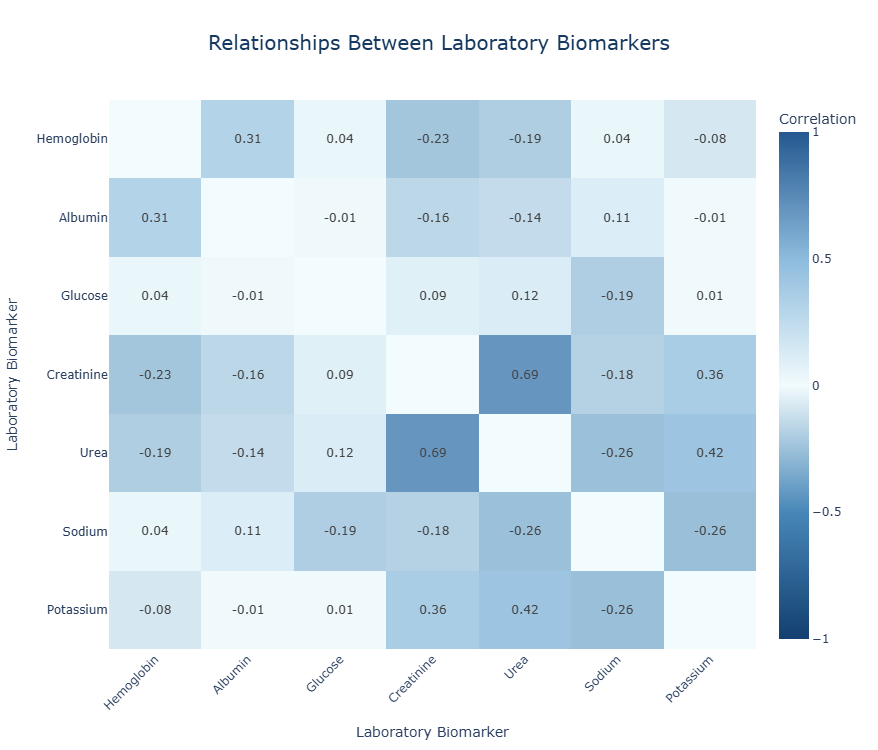

In [82]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from itertools import combinations

# --------------------------------------------------
# 1. Select laboratory biomarkers
# --------------------------------------------------

lab_options = {
    "Hemoglobin": [
        "hemoglobin",
        "hemoglobin_blood_gas"
    ],

    "Albumin": [
        "albumin",
        "albumin_serum"
    ],
    "Glucose": [
        "glucose_blood_gas",
        "glucose"
    ],

    "Creatinine": [
        "creatinine_enzymatic_method",
        "creatinine"
    ],

    "Urea": [
        "urea"
    ],

    "Troponin": [
        "troponin_i",
        "troponin_t",
        "troponin"
    ],

    "BNP": [
        "bnp",
        "nt_probnp",
        "nt_pro_bnp"
    ],

    "Sodium": [
        "sodium"
    ],

    "Potassium": [
        "potassium"
    ]
}

# Identify available biomarkers
selected_labs = {}

for label, options in lab_options.items():

    col = next(
        (c for c in options if c in patient.columns),
        None
    )

    if col:
        selected_labs[label] = col

if len(selected_labs) < 2:
    raise ValueError(
        "At least two laboratory biomarkers are required."
    )


# --------------------------------------------------
# 2. Prepare laboratory data
# --------------------------------------------------

tmp = patient[
    ["inpatient_number"] + list(selected_labs.values())
].copy()

# Convert laboratory measurements to numeric
for col in selected_labs.values():

    tmp[col] = pd.to_numeric(
        tmp[col],
        errors="coerce"
    )

# Use one value per inpatient number.
# If multiple results exist, use their median.
tmp = (
    tmp.groupby("inpatient_number")[
        list(selected_labs.values())
    ]
    .median()
)

# Rename columns for better readability
tmp = tmp.rename(
    columns={
        col: label
        for label, col in selected_labs.items()
    }
)

# Keep biomarkers with at least 30 available records
MIN_PAIR_N = 30

available_labs = [
    col for col in tmp.columns
    if tmp[col].notna().sum() >= MIN_PAIR_N
    and tmp[col].nunique() > 1
]

tmp = tmp[available_labs]

if len(available_labs) < 2:
    raise ValueError(
        "Not enough laboratory measurements for correlation analysis."
    )


# --------------------------------------------------
# 3. Calculate correlations
# --------------------------------------------------

correlation = tmp.corr(
    method="spearman",
    min_periods=MIN_PAIR_N
)

# Count records with both laboratory measurements
count_data = pd.DataFrame(
    np.nan,
    index=available_labs,
    columns=available_labs
)

for first, second in combinations(
    available_labs,
    2
):

    count = tmp[
        [first, second]
    ].dropna().shape[0]

    if count >= MIN_PAIR_N:

        count_data.loc[first, second] = count
        count_data.loc[second, first] = count


# Remove the diagonal
for col in available_labs:

    correlation.loc[col, col] = np.nan


# --------------------------------------------------
# 4. Prepare heatmap labels
# --------------------------------------------------

heatmap_text = [
    [
        f"{value:.2f}"
        if pd.notna(value)
        else ""

        for value in row
    ]

    for row in correlation.values
]


# --------------------------------------------------
# 5. Create correlation heatmap
# --------------------------------------------------

fig = go.Figure(

    go.Heatmap(

        z=correlation.values,

        x=correlation.columns,

        y=correlation.index,

        zmin=-1,

        zmax=1,

        zmid=0,

        colorscale=[
            [0.00, "#123F70"],
            [0.25, "#4787B8"],
            [0.50, "#F2FBFD"],
            [0.75, "#8DBBDD"],
            [1.00, "#24588F"]
        ],

        text=heatmap_text,

        texttemplate="%{text}",

        textfont=dict(
            size=12
        ),

        customdata=count_data.values,

        hovertemplate=(
            "<b>%{y} and %{x}</b><br><br>"
            "Correlation: %{z:.2f}<br>"
            "Records with both tests: %{customdata:.0f}"
            "<extra></extra>"
        ),

        colorbar=dict(
            title="Correlation",
            tickvals=[-1, -0.5, 0, 0.5, 1]
        ),

        hoverongaps=False
    )
)


# --------------------------------------------------
# 6. Customize chart
# --------------------------------------------------

fig.update_layout(

    title=dict(
        text="Relationships Between Laboratory Biomarkers",
        x=0.5,

        font=dict(
            size=20,
            color="#16395F"
        )
    ),

    height=750,

    paper_bgcolor="white",

    plot_bgcolor="#F2FBFD",

    xaxis=dict(
        title="Laboratory Biomarker",
        showgrid=False,
        tickangle=-45
    ),

    yaxis=dict(
        title="Laboratory Biomarker",
        showgrid=False,
        autorange="reversed"
    ),

    font=dict(size=12)
)

fig.show()


* Actual Insight:
* 
Creatinine and urea showed the clearest relationship (0.69), meaning both measurements generally increase together. Urea and potassium also showed a positive relationship (0.42), followed by creatinine and potassium (0.36).
Hemoglobin and albumin showed a smaller positive relationship (0.31), while glucose had little relationship with most of the other biomarkers.
These findings suggest that reviewing kidney-related measurements together may provide a better understanding of patient laboratory results.

# PA4: Which age groups show the greatest differences in laboratory values, and which specific lab measurements may require closer clinical attention? 
* Sankey Chart: Laboratory Result Flow Across Age Groups — Prescriptive Analysis *
* Reasoning *

Comparing hemoglobin, albumin, glucose, creatinine, and urea across age groups helps us understand how laboratory results differ among patients. A Sankey chart shows how these measurements are distributed into above, within, and below comparison ranges, helping identify patterns that may need further review.

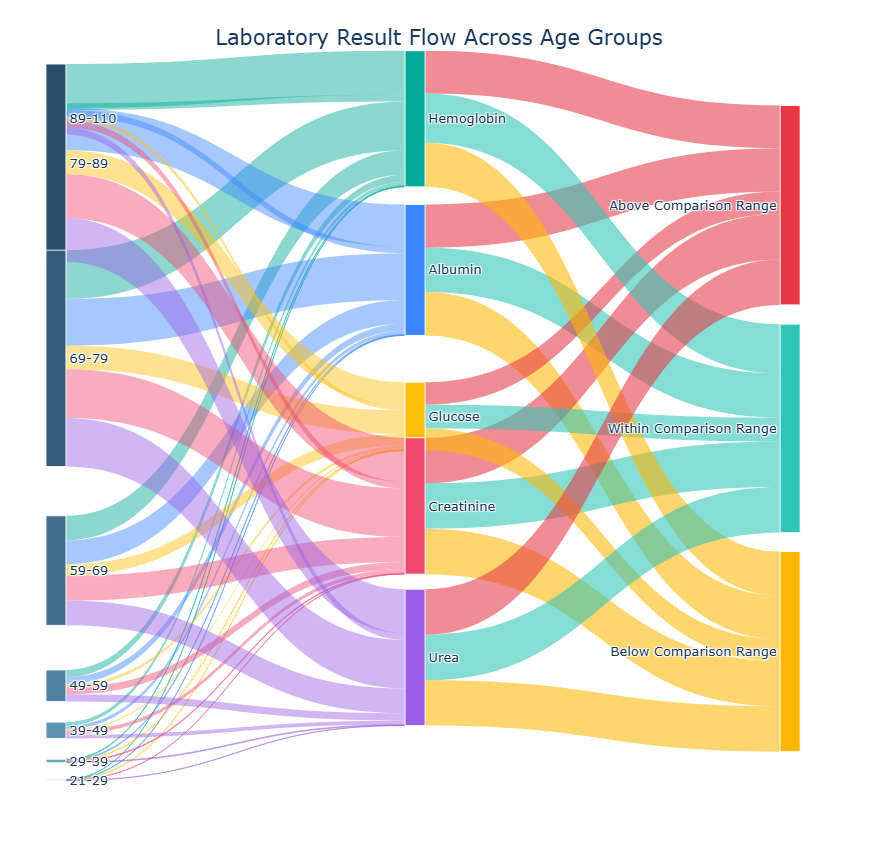

In [110]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import re

# --------------------------------------------------
# 1. Select laboratory biomarkers
# --------------------------------------------------

lab_options = {
    "Hemoglobin": ["hemoglobin", "hemoglobin_blood_gas"],
    "Albumin": ["albumin", "albumin_serum"],
    "Glucose": ["glucose_blood_gas", "glucose"],
    "Creatinine": ["creatinine_enzymatic_method", "creatinine"],
    "Urea": ["urea"]
}

selected_labs = {}

for label, options in lab_options.items():
    col = next((c for c in options if c in patient.columns), None)
    if col:
        selected_labs[label] = col

if not selected_labs:
    raise ValueError("No laboratory biomarkers found.")


# --------------------------------------------------
# 2. Define result categories
# --------------------------------------------------

ABOVE = "Above Comparison Range"
WITHIN = "Within Comparison Range"
BELOW = "Below Comparison Range"

# Keep this exact order for the last column
result_categories = [ABOVE, WITHIN, BELOW]


# --------------------------------------------------
# 3. Prepare laboratory data
# --------------------------------------------------

results = []

for label, col in selected_labs.items():

    tmp = patient[["inpatient_number", "agecat", col]].copy()

    tmp[col] = pd.to_numeric(tmp[col], errors="coerce")
    tmp[col] = tmp[col].replace([np.inf, -np.inf], np.nan)
    tmp = tmp.dropna()

    if tmp.empty:
        continue

    # Keep one measurement per inpatient number and age group
    tmp = (
        tmp.groupby(
            ["inpatient_number", "agecat"],
            observed=True,
            as_index=False
        )[col]
        .median()
    )

    # Comparison limits based on dataset thirds
    lower = tmp[col].quantile(1/3)
    upper = tmp[col].quantile(2/3)

    if lower >= upper:
        continue

    # Classify results
    tmp["Lab Result"] = np.select(
        [
            tmp[col] > upper,
            tmp[col] < lower
        ],
        [
            ABOVE,
            BELOW
        ],
        default=WITHIN
    )

    tested = (
        tmp.groupby("agecat", observed=True)
        .size()
        .rename("Tested Patients")
        .reset_index()
    )

    summary = (
        tmp.groupby(
            ["agecat", "Lab Result"],
            observed=True
        )
        .size()
        .reset_index(name="Patient Count")
    )

    summary = summary.merge(
        tested,
        on="agecat",
        how="left"
    )

    summary["Biomarker"] = label
    summary["Patient Percentage"] = (
        summary["Patient Count"] / summary["Tested Patients"] * 100
    )

    results.append(summary)

if not results:
    raise ValueError("No laboratory results available.")

sankey_df = pd.concat(results, ignore_index=True)
sankey_df = sankey_df.rename(columns={"agecat": "Age Category"})
sankey_df["Age Category"] = sankey_df["Age Category"].astype(str)


# --------------------------------------------------
# 4. Define improved colors
# --------------------------------------------------

# Richer biomarker colors
lab_colors = {
    "Hemoglobin": "#00A896",   # bright teal
    "Albumin": "#3A86FF",      # vivid blue
    "Glucose": "#FFBE0B",      # bright yellow
    "Creatinine": "#EF476F",   # vivid pink-red
    "Urea": "#9B5DE5"          # vibrant purple
}

# Age-group colors: darker blue-teal family
age_colors = [
    "#1D3557",
    "#2A4D69",
    "#355C7D",
    "#436F8E",
    "#4F81A0",
    "#5C93B1",
    "#6AA5C2",
    "#78B7D3"
]

# Result-category colors
result_colors = {
    ABOVE: "#E63946",   # vivid red
    WITHIN: "#2EC4B6",  # brighter teal
    BELOW: "#FFB703"    # brighter yellow
}


# --------------------------------------------------
# 5. Create correctly ordered node lists
# --------------------------------------------------

def age_sort_key(age):
    nums = re.findall(r"\d+", str(age))
    return int(nums[0]) if nums else -1

# DESCENDING age order
age_nodes = sorted(
    sankey_df["Age Category"].unique(),
    key=age_sort_key,
    reverse=True
)

lab_nodes = [lab for lab in lab_options if lab in sankey_df["Biomarker"].unique()]
result_nodes = [r for r in result_categories if r in sankey_df["Lab Result"].unique()]

age_ids = [f"age:{x}" for x in age_nodes]
lab_ids = [f"lab:{x}" for x in lab_nodes]
result_ids = [f"result:{x}" for x in result_nodes]

all_ids = age_ids + lab_ids + result_ids
all_labels = age_nodes + lab_nodes + result_nodes

node_map = {node_id: i for i, node_id in enumerate(all_ids)}


# --------------------------------------------------
# 6. Create Sankey connections
# --------------------------------------------------

links_1 = (
    sankey_df.groupby(
        ["Age Category", "Biomarker"],
        observed=True
    )["Patient Count"]
    .sum()
    .reset_index()
)

links_2 = (
    sankey_df.groupby(
        ["Biomarker", "Lab Result"],
        observed=True
    )["Patient Count"]
    .sum()
    .reset_index()
)

source = (
    [node_map[f"age:{age}"] for age in links_1["Age Category"]] +
    [node_map[f"lab:{lab}"] for lab in links_2["Biomarker"]]
)

target = (
    [node_map[f"lab:{lab}"] for lab in links_1["Biomarker"]] +
    [node_map[f"result:{result}"] for result in links_2["Lab Result"]]
)

values = (
    links_1["Patient Count"].tolist() +
    links_2["Patient Count"].tolist()
)


# --------------------------------------------------
# 7. Assign node colors
# --------------------------------------------------

node_colors = []

for label in all_labels:
    if label in age_nodes:
        node_colors.append(age_colors[age_nodes.index(label) % len(age_colors)])
    elif label in lab_nodes:
        node_colors.append(lab_colors[label])
    else:
        node_colors.append(result_colors[label])


# --------------------------------------------------
# 8. Create transparent link colors
# --------------------------------------------------

def hex_to_rgba(hex_color, opacity=0.55):
    hex_color = hex_color.lstrip("#")
    r = int(hex_color[0:2], 16)
    g = int(hex_color[2:4], 16)
    b = int(hex_color[4:6], 16)
    return f"rgba({r},{g},{b},{opacity})"

link_colors = []

# Age -> Biomarker links use biomarker colors
for lab in links_1["Biomarker"]:
    link_colors.append(hex_to_rgba(lab_colors[lab], opacity=0.45))

# Biomarker -> Result links use result colors
for result in links_2["Lab Result"]:
    link_colors.append(hex_to_rgba(result_colors[result], opacity=0.58))


# --------------------------------------------------
# 9. Position nodes
# --------------------------------------------------

CHART_HEIGHT = 850
PLOT_HEIGHT = 730
NODE_PAD = 16

total_flow = links_1["Patient Count"].sum()
max_nodes = max(len(age_nodes), len(lab_nodes), len(result_nodes))
usable_height = PLOT_HEIGHT * 0.92

flow_scale = (
    usable_height - (max_nodes - 1) * NODE_PAD
) / total_flow


def calculate_positions(labels, counts):
    counts = np.array(counts, dtype=float)
    total_node_height = counts.sum() * flow_scale

    if len(labels) > 1:
        gap = (usable_height - total_node_height) / (len(labels) - 1)
    else:
        gap = 0

    positions = []
    current_y = PLOT_HEIGHT * 0.04

    for count in counts:
        positions.append(current_y / PLOT_HEIGHT)
        current_y += count * flow_scale + gap

    return positions


# Age-group positions (descending order already set)
age_counts = (
    links_1.groupby("Age Category")["Patient Count"]
    .sum()
    .reindex(age_nodes)
    .fillna(0)
)
age_y = calculate_positions(age_nodes, age_counts.values)

# Biomarker positions
lab_counts = (
    links_1.groupby("Biomarker")["Patient Count"]
    .sum()
    .reindex(lab_nodes)
    .fillna(0)
)
lab_y = calculate_positions(lab_nodes, lab_counts.values)

# Result positions: top -> above, middle -> within, bottom -> below
result_y_map = {
    ABOVE: 0.16,
    WITHIN: 0.47,
    BELOW: 0.78
}
result_y = [result_y_map[r] for r in result_nodes]

x_positions = (
    [0.02] * len(age_nodes) +
    [0.47] * len(lab_nodes) +
    [0.94] * len(result_nodes)
)

y_positions = age_y + lab_y + result_y


# --------------------------------------------------
# 10. Create Sankey chart
# --------------------------------------------------

fig = go.Figure(
    go.Sankey(
        arrangement="fixed",

        node=dict(
            pad=NODE_PAD,
            thickness=20,
            line=dict(color="white", width=0.9),
            label=all_labels,
            color=node_colors,
            x=x_positions,
            y=y_positions,
            hovertemplate=(
                "<b>%{label}</b><br>"
                "Count: %{value:,.0f}"
                "<extra></extra>"
            )
        ),

        link=dict(
            source=source,
            target=target,
            value=values,
            color=link_colors,
            hovertemplate=(
                "<b>%{source.label}</b> → <b>%{target.label}</b><br>"
                "Count: %{value:,.0f}"
                "<extra></extra>"
            )
        )
    )
)


# --------------------------------------------------
# 11. Customize chart appearance
# --------------------------------------------------

fig.update_layout(
    title=dict(
        text="Laboratory Result Flow Across Age Groups",
        x=0.5,
        font=dict(
            size=21,
            color="#16395F"
        )
    ),
    height=CHART_HEIGHT,
    paper_bgcolor="white",
    plot_bgcolor="white",
    font=dict(
        size=13,
        color="#16395F"
    ),
    margin=dict(
        t=90,
        l=40,
        r=40,
        b=40
    )
)

fig.show()


* Actual Insight

The chart shows that older age groups, particularly 69–79 and 79–89, account for a larger number of laboratory results across the different comparison ranges. Hemoglobin, albumin, glucose, creatinine, and urea show different distributions across these groups. This helps identify which laboratory measurements may need closer attention when reviewing older patients.

# PA5: Among patients receiving multiple medications, which age groups show the greatest medication burden, and how do their glucose levels differ across these groups? 

## Prescription Medication and Laboratory Results — Sunburst Chart
### Reasoning

Combining prescription records with glucose measurements helps us understand how laboratory results vary among patients taking different numbers of medications. A Sunburst chart shows these patterns across age groups, making it easier to identify patient groups that may benefit from further laboratory and medication review.

Medication column: drug_name


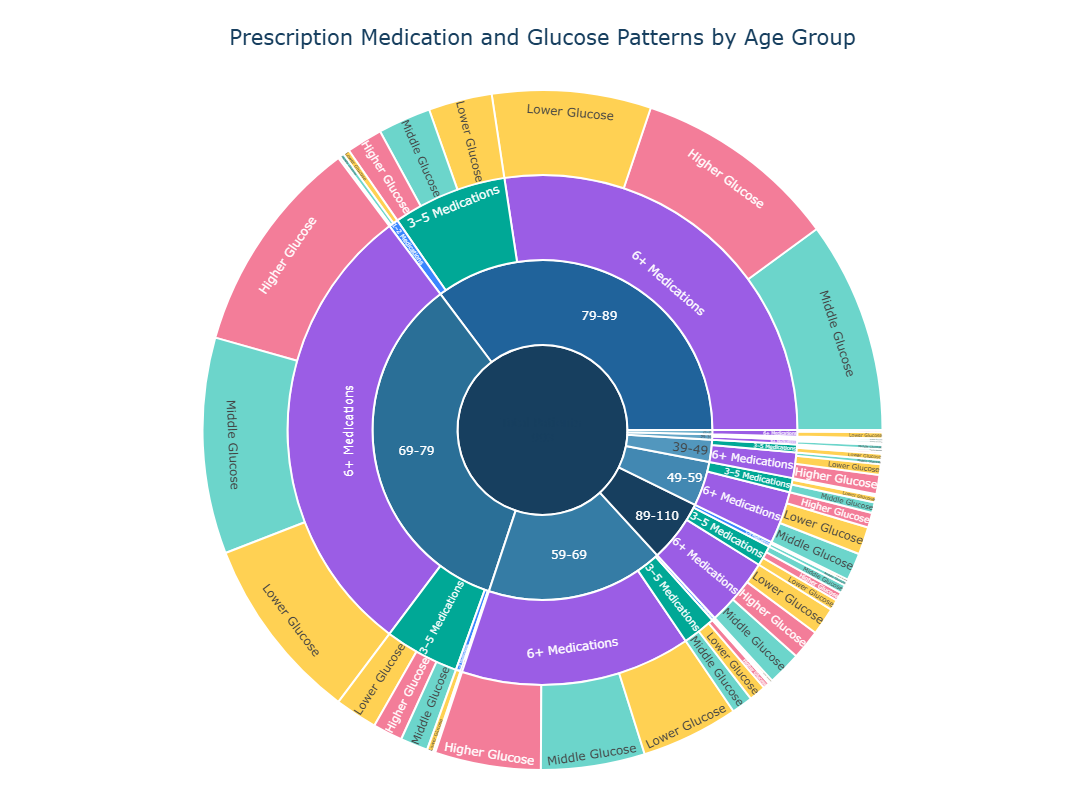

In [122]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import re

# --------------------------------------------------
# 1. Define columns
# --------------------------------------------------

ID_COL = "inpatient_number"
AGE_COL = "agecat"
GLUCOSE_COL = "glucose_blood_gas"

# Identify medication column
med_options = [
    "drug_name",
    "medication_name",
    "medicine_name",
    "prescription_name",
    "generic_name",
    "drug",
    "medication",
    "medicine",
    "drug_class",
    "drug_code"
]

MED_COL = next(
    (col for col in med_options if col in prescriptions.columns),
    None
)

if MED_COL is None:

    print("Available prescription columns:")
    print(prescriptions.columns.tolist())

    raise ValueError(
        "Please select the correct medication column."
    )

print("Medication column:", MED_COL)


# --------------------------------------------------
# 2. Prepare patient and glucose data
# --------------------------------------------------

tmp = patient[
    [ID_COL, AGE_COL, GLUCOSE_COL]
].copy()

tmp[GLUCOSE_COL] = pd.to_numeric(
    tmp[GLUCOSE_COL],
    errors="coerce"
)

tmp[GLUCOSE_COL] = tmp[GLUCOSE_COL].replace(
    [np.inf, -np.inf],
    np.nan
)

tmp = tmp.dropna(
    subset=[ID_COL, AGE_COL, GLUCOSE_COL]
)

# Standardize inpatient IDs
tmp[ID_COL] = (
    tmp[ID_COL]
    .astype(str)
    .str.strip()
)

# Keep one glucose measurement per inpatient ID
# Use the median if multiple results are available
glucose_data = (
    tmp.groupby(
        ID_COL,
        as_index=False
    )
    .agg({
        AGE_COL: "first",
        GLUCOSE_COL: "median"
    })
)


# --------------------------------------------------
# 3. Count distinct prescribed medications
# --------------------------------------------------

med_data = prescriptions[
    [ID_COL, MED_COL]
].copy()

med_data = med_data.dropna()

med_data[ID_COL] = (
    med_data[ID_COL]
    .astype(str)
    .str.strip()
)

med_data[MED_COL] = (
    med_data[MED_COL]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Remove blank medication names
med_data = med_data[
    med_data[MED_COL] != ""
]

# Count unique medication names per inpatient ID
med_counts = (
    med_data.groupby(ID_COL)[MED_COL]
    .nunique()
    .reset_index(name="Medication Count")
)

# Combine glucose and prescription information
sunburst_data = glucose_data.merge(
    med_counts,
    on=ID_COL,
    how="left"
)

# No matching prescription record
sunburst_data["Medication Count"] = (
    sunburst_data["Medication Count"]
    .fillna(0)
    .astype(int)
)


# --------------------------------------------------
# 4. Create medication categories
# --------------------------------------------------

def medication_group(count):

    if count == 0:
        return "No Prescription Listed"

    elif count <= 2:
        return "1–2 Medications"

    elif count <= 5:
        return "3–5 Medications"

    else:
        return "6+ Medications"


sunburst_data["Medication Group"] = (
    sunburst_data["Medication Count"]
    .apply(medication_group)
)


# --------------------------------------------------
# 5. Create glucose comparison categories
# --------------------------------------------------

lower = sunburst_data[GLUCOSE_COL].quantile(1/3)
upper = sunburst_data[GLUCOSE_COL].quantile(2/3)

if lower >= upper:
    raise ValueError(
        "Glucose values cannot be divided into three distinct groups."
    )

sunburst_data["Glucose Level"] = np.select(

    [
        sunburst_data[GLUCOSE_COL] < lower,
        sunburst_data[GLUCOSE_COL] > upper
    ],

    [
        "Lower Glucose",
        "Higher Glucose"
    ],

    default="Middle Glucose"
)


# --------------------------------------------------
# 6. Prepare summary for Sunburst
# --------------------------------------------------

sunburst_data["Age Category"] = (
    sunburst_data[AGE_COL].astype(str)
)

summary = (
    sunburst_data.groupby(
        [
            "Age Category",
            "Medication Group",
            "Glucose Level"
        ],
        observed=True
    )
    .size()
    .reset_index(name="Patient Count")
)

# Total tested patients in each age and medication group
summary["Tested Patients"] = (
    summary.groupby(
        ["Age Category", "Medication Group"]
    )["Patient Count"]
    .transform("sum")
)

summary["Patient Percentage"] = (
    summary["Patient Count"]
    / summary["Tested Patients"]
    * 100
)


# --------------------------------------------------
# 7. Define colors
# --------------------------------------------------

age_colors = [
    "#173F5F",
    "#20639B",
    "#2A6F97",
    "#357CA5",
    "#4288B2",
    "#5297BE",
    "#63A5C6",
    "#74B3CE"
]

med_colors = {
    "No Prescription Listed": "#94A3B8",
    "1–2 Medications": "#3A86FF",
    "3–5 Medications": "#00A896",
    "6+ Medications": "#9B5DE5"
}

glucose_colors = {
    "Lower Glucose": "#FFBE0B",
    "Middle Glucose": "#2EC4B6",
    "Higher Glucose": "#EF476F"
}


# --------------------------------------------------
# 8. Define category order
# --------------------------------------------------

def age_sort_key(age):

    numbers = re.findall(
        r"\d+",
        str(age)
    )

    return int(numbers[0]) if numbers else -1


age_nodes = sorted(
    summary["Age Category"].unique(),
    key=age_sort_key,
    reverse=True
)

med_nodes = [
    "No Prescription Listed",
    "1–2 Medications",
    "3–5 Medications",
    "6+ Medications"
]

glucose_nodes = [
    "Higher Glucose",
    "Middle Glucose",
    "Lower Glucose"
]


# --------------------------------------------------
# 9. Build Sunburst hierarchy
# --------------------------------------------------

nodes = []

def add_node(node_id, label, parent, count, color, hover):

    nodes.append({
        "id": node_id,
        "label": label,
        "parent": parent,
        "value": int(count),
        "color": color,
        "hover": hover
    })


# Main circle - Total Patients

total_patients = int(
    summary["Patient Count"].sum()
)

add_node(
    "root",
    f"Total Patients<br>{total_patients:,}",
    "",
    total_patients,
    "#173F5F",
    (
        f"<b>Total Patients: {total_patients:,}</b><br>"
    )
)


# Age groups
for i, age in enumerate(age_nodes):

    age_data = summary[
        summary["Age Category"] == age
    ]

    age_id = f"age:{age}"

    age_count = age_data["Patient Count"].sum()

    add_node(
        age_id,
        age,
        "root",
        age_count,
        age_colors[i % len(age_colors)],
        (
            f"<b>Age Group: {age}</b><br>"
            f"Tested Patients: {int(age_count):,}"
        )
    )

    # Medication groups
    for med in med_nodes:

        med_data_group = age_data[
            age_data["Medication Group"] == med
        ]

        if med_data_group.empty:
            continue

        med_id = f"{age_id}|med:{med}"

        med_count = med_data_group[
            "Patient Count"
        ].sum()

        add_node(
            med_id,
            med,
            age_id,
            med_count,
            med_colors[med],
            (
                f"<b>{med}</b><br>"
                f"Age Group: {age}<br>"
                f"Patient Count: {int(med_count):,}"
            )
        )

        # Glucose categories
        for glucose in glucose_nodes:

            glucose_data_group = med_data_group[
                med_data_group["Glucose Level"] == glucose
            ]

            if glucose_data_group.empty:
                continue

            row = glucose_data_group.iloc[0]

            count = int(row["Patient Count"])
            tested = int(row["Tested Patients"])
            percentage = float(row["Patient Percentage"])

            add_node(
                f"{med_id}|glucose:{glucose}",
                glucose,
                med_id,
                count,
                glucose_colors[glucose],

                (
                    f"<b>{glucose}</b><br>"
                    f"Age Group: {age}<br>"
                    f"Medication Group: {med}<br>"
                    f"Patient Count: {count:,}<br>"
                    f"Tested Patients: {tested:,}<br>"
                    f"Patient Percentage: {percentage:.1f}%"
                )
            )


# --------------------------------------------------
# 10. Create Sunburst chart
# --------------------------------------------------

fig = go.Figure(

    go.Sunburst(

        ids=[
            n["id"]
            for n in nodes
        ],

        labels=[
            n["label"]
            for n in nodes
        ],

        parents=[
            n["parent"]
            for n in nodes
        ],

        values=[
            n["value"]
            for n in nodes
        ],

        branchvalues="total",

        marker=dict(
            colors=[
                n["color"]
                for n in nodes
            ],

            line=dict(
                color="white",
                width=2
            )
        ),

        customdata=[
            n["hover"]
            for n in nodes
        ],

        hovertemplate=(
            "%{customdata}"
            "<extra></extra>"
        ),

        text=[
            f"Total Patients <br>{total_patients:,}"
                if n["id"] == "root"
                else n["label"]
                for n in nodes
            ],

        textinfo="text",
        texttemplate="%{text}",
        insidetextorientation="auto",
        maxdepth=4

    )
)


# --------------------------------------------------
# 11. Customize chart appearance
# --------------------------------------------------

fig.update_layout(

    title=dict(
        text="Prescription Medication and Glucose Patterns by Age Group",
        x=0.5,
        font=dict(
            size=21,
            color="#173F5F"
        )
    ),

    height=800,

    paper_bgcolor="white",

    font=dict(
        size=12,
        color="#173F5F"
    ),

    margin=dict(
        t=90,
        l=30,
        r=30,
        b=30
    )
)

fig.show()



## Actual Insight:
The code will automatically identify the age and medication group with the highest percentage of higher glucose measurements, among groups with at least 30 tested inpatient records.

You can use that output as the starting point for your notebook's Actual Insight. We should describe the specific age group, medication count, and percentage after you execute it.

## PA6: Which age groups demonstrate higher medication utilization patterns that may warrant closer review of medication management and potential treatment burden?
## Reasoning

Comparing medication usage across age groups helps us understand which medications are more commonly prescribed to different patient groups. A heatmap makes it easier to identify noticeable differences in medication usage and highlight groups where prescription patterns may need further investigation.

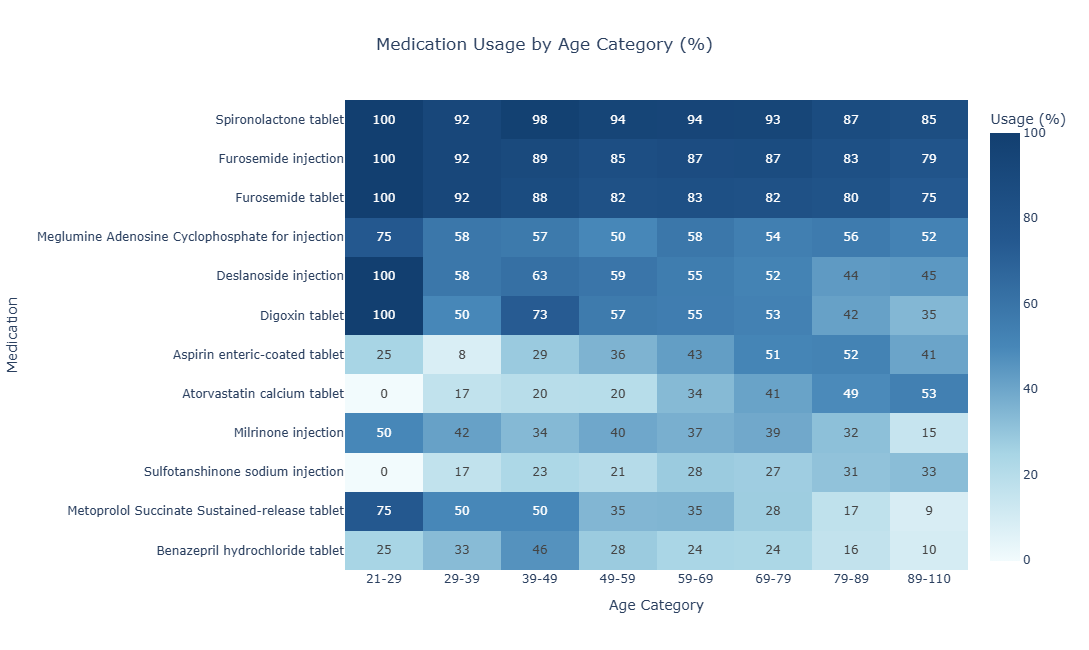

In [128]:
import pandas as pd
import plotly.express as px
import re

# --------------------------------------------------
# 1. Prepare patient and prescription data
# --------------------------------------------------

patient_data = patient[
    ["inpatient_number", "agecat"]
].copy()

rx_data = rx[
    ["inpatient_number", "drug_name"]
].copy()

# Remove missing values
patient_data = patient_data.dropna()
rx_data = rx_data.dropna()

# Standardize inpatient IDs
patient_data["inpatient_number"] = (
    patient_data["inpatient_number"].astype(str).str.strip()
)

rx_data["inpatient_number"] = (
    rx_data["inpatient_number"].astype(str).str.strip()
)

# Standardize medication names
rx_data["drug_name"] = (
    rx_data["drug_name"].astype(str).str.strip()
)

rx_data = rx_data[
    rx_data["drug_name"] != ""
]

# Keep one record per inpatient ID
patient_data = patient_data.drop_duplicates(
    subset=["inpatient_number"]
)

# Keep prescription records belonging to the patient cohort
rx_data = rx_data[
    rx_data["inpatient_number"].isin(
        patient_data["inpatient_number"]
    )
]

# --------------------------------------------------
# 2. Identify top 12 medications
# --------------------------------------------------

top_drugs = (
    rx_data.drop_duplicates(
        ["inpatient_number", "drug_name"]
    )["drug_name"]
    .value_counts()
    .head(12)
    .index
    .tolist()
)

if not top_drugs:
    raise ValueError(
        "No matching prescription records were found."
    )

# --------------------------------------------------
# 3. Calculate total patients in each age group
# --------------------------------------------------

age_counts = (
    patient_data.groupby(
        "agecat",
        observed=True
    )["inpatient_number"]
    .nunique()
)

# --------------------------------------------------
# 4. Calculate medication usage by age group
# --------------------------------------------------

# Attach age category to prescription records
rx_with_age = rx_data.merge(
    patient_data,
    on="inpatient_number",
    how="inner"
)

# Keep the top 12 medications
rx_with_age = rx_with_age[
    rx_with_age["drug_name"].isin(top_drugs)
]

# Count each inpatient ID once per medication
rx_with_age = rx_with_age.drop_duplicates(
    ["inpatient_number", "drug_name"]
)

# Count patients using each medication
med_counts = (
    rx_with_age.groupby(
        ["agecat", "drug_name"],
        observed=True
    )["inpatient_number"]
    .nunique()
    .unstack(fill_value=0)
)

# Include all age groups and selected medications
med_counts = med_counts.reindex(
    index=age_counts.index,
    columns=top_drugs,
    fill_value=0
)

# Calculate medication usage percentage
age_med_usage_pct = (
    med_counts.div(age_counts, axis=0)
    .mul(100)
)

# --------------------------------------------------
# 5. Arrange age categories
# --------------------------------------------------

def age_sort_key(age):
    numbers = re.findall(r"\d+", str(age))
    return int(numbers[0]) if numbers else -1

age_order = sorted(
    age_med_usage_pct.index,
    key=age_sort_key
)

age_med_usage_pct = age_med_usage_pct.reindex(
    age_order
)

# --------------------------------------------------
# 6. Create medication usage heatmap
# --------------------------------------------------

fig = px.imshow(
    age_med_usage_pct.T,

    aspect="auto",

    text_auto=".0f",

    title="Medication Usage by Age Category (%)",

    labels={
        "x": "Age Category",
        "y": "Medication",
        "color": "Usage (%)"
    },

    color_continuous_scale=[
        "#F2FBFD",
        "#A8D5E5",
        "#4787B8",
        "#24588F",
        "#123F70"
    ]
)

fig.update_layout(
    height=650,
    title_x=0.5,
    paper_bgcolor="white",
    plot_bgcolor="#F2FBFD",
    font=dict(size=12),

    xaxis=dict(
        showgrid=False
    ),

    yaxis=dict(
        showgrid=False
    )
)

fig.show()



## Actual Insight

<b> Spironolactone and furosemide are the most commonly used medications across almost all age groups, with usage remaining above 75%. Atorvastatin usage generally increases with age, reaching 53% among patients aged 89–110. In contrast, metoprolol succinate usage decreases across the older age groups, reaching 9% in the oldest group.
These patterns show that medication usage varies with age and highlight differences that may be useful for further prescription review. </b>

## PA7. Which age groups show differences in laboratory measurements and blood pressure that may need closer attention?
## Laboratory and Blood Pressure Profiles by Age Category
## Reasoning
Comparing hemoglobin, glucose, creatinine, and systolic blood pressure across age groups helps us understand how these health measurements are related. A Pair Plot shows how the measurements vary together and helps identify age groups with patterns that may need further review.

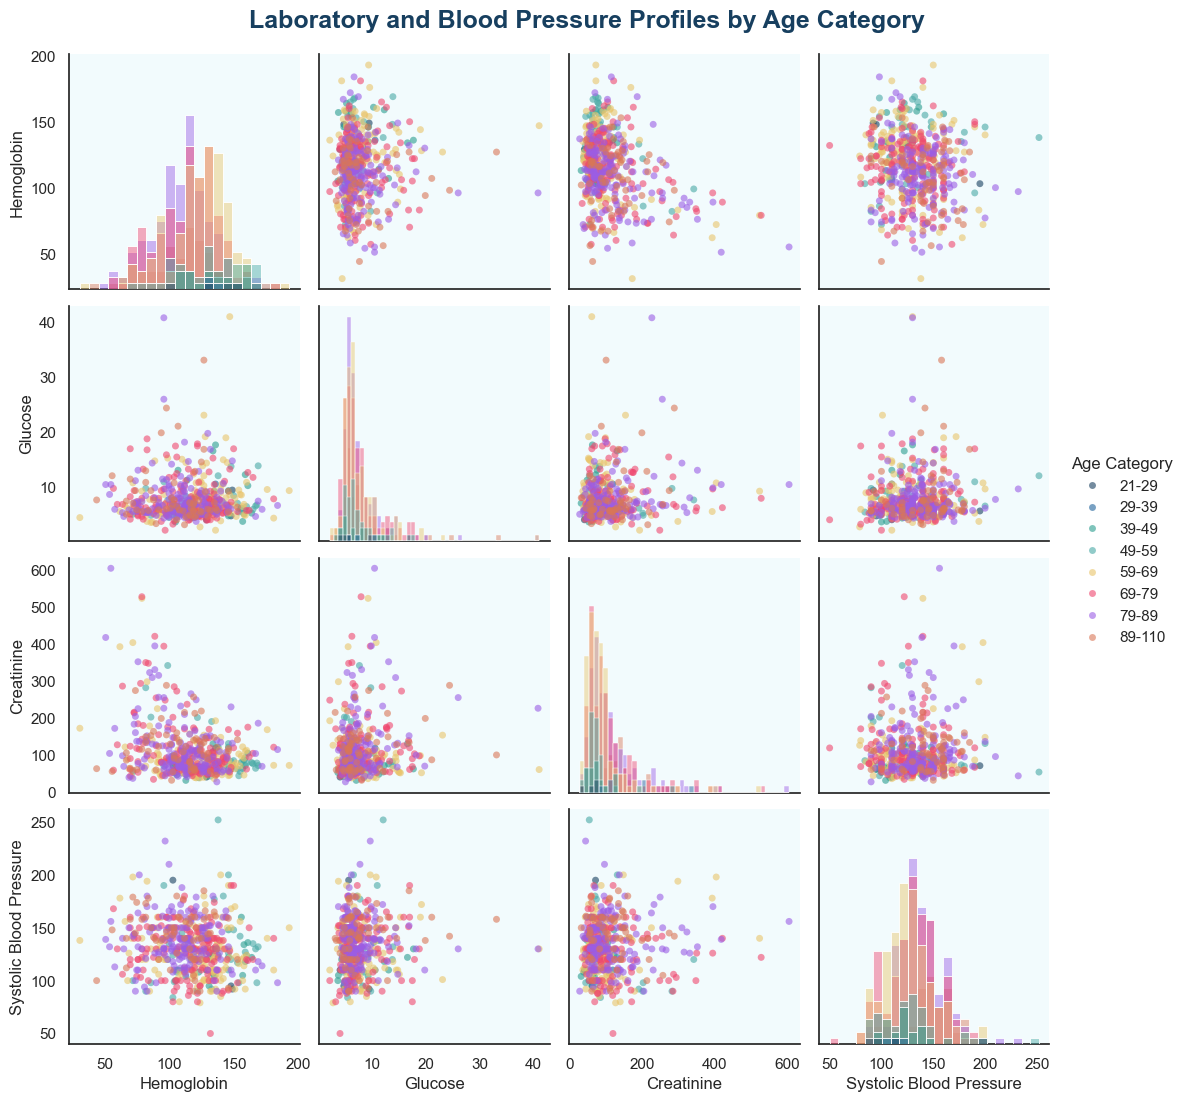

In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# --------------------------------------------------
# 1. Select laboratory and blood pressure measurements
# --------------------------------------------------

selected_columns = {
    "hemoglobin": "Hemoglobin",
    "glucose_blood_gas": "Glucose",
    "creatinine_enzymatic_method": "Creatinine",
    "systolic_blood_pressure": "Systolic Blood Pressure"
}

# Check available columns
available_columns = {
    col: label
    for col, label in selected_columns.items()
    if col in patient.columns
}

if len(available_columns) < 3:
    raise ValueError(
        "At least three measurements are required."
    )


# --------------------------------------------------
# 2. Prepare patient data
# --------------------------------------------------

tmp = patient[
    ["inpatient_number", "agecat"]
    + list(available_columns.keys())
].copy()

# Convert measurements to numeric
for col in available_columns:

    tmp[col] = pd.to_numeric(
        tmp[col],
        errors="coerce"
    )

    tmp[col] = tmp[col].replace(
        [np.inf, -np.inf],
        np.nan
    )

# Remove records without age or inpatient number
tmp = tmp.dropna(
    subset=["inpatient_number", "agecat"]
)

# Keep one laboratory profile per inpatient number
tmp = (
    tmp.groupby(
        "inpatient_number",
        as_index=False
    )
    .agg({
        "agecat": "first",
        **{
            col: "median"
            for col in available_columns
        }
    })
)

# Rename columns
tmp = tmp.rename(
    columns=available_columns
)

tmp = tmp.rename(
    columns={"agecat": "Age Category"}
)

markers = list(available_columns.values())

# Keep complete profiles
tmp = tmp.dropna(
    subset=markers
)

if tmp.empty:
    raise ValueError(
        "No complete laboratory profiles available."
    )


# --------------------------------------------------
# 3. Arrange age categories
# --------------------------------------------------

def age_sort_key(age):

    numbers = re.findall(
        r"\d+",
        str(age)
    )

    return int(numbers[0]) if numbers else -1


tmp["Age Category"] = (
    tmp["Age Category"].astype(str)
)

age_order = sorted(
    tmp["Age Category"].unique(),
    key=age_sort_key
)


# --------------------------------------------------
# 4. Define colors
# --------------------------------------------------

colors = [
    "#173F5F",
    "#20639B",
    "#2A9D8F",
    "#48A9A6",
    "#E9C46A",
    "#EF476F",
    "#9B5DE5",
    "#D97757"
]

palette = {
    age: colors[i % len(colors)]
    for i, age in enumerate(age_order)
}


# --------------------------------------------------
# 5. Prepare data for visualization
# --------------------------------------------------

# Use a maximum of 150 records per age category
# to prevent too many overlapping points.

MAX_PER_AGE = 150

plot_data = pd.concat(
    [
        group.sample(
            n=min(len(group), MAX_PER_AGE),
            random_state=42
        )

        for _, group in tmp.groupby(
            "Age Category"
        )
    ],
    ignore_index=True
)


# --------------------------------------------------
# 6. Create Pair Plot
# --------------------------------------------------

sns.set_theme(
    style="white",
    font_scale=1.0
)

g = sns.pairplot(

    data=plot_data,

    vars=markers,

    hue="Age Category",

    hue_order=age_order,

    palette=palette,

    diag_kind="hist",

    diag_kws={
        "alpha": 0.45
    },

    plot_kws={
        "alpha": 0.60,
        "s": 25,
        "edgecolor": "none"
    },

    height=2.7,

    aspect=1
)


# --------------------------------------------------
# 7. Customize chart
# --------------------------------------------------

g.fig.suptitle(
    "Laboratory and Blood Pressure Profiles by Age Category",
    fontsize=18,
    fontweight="bold",
    color="#173F5F",
    y=1.02
)

g.fig.set_facecolor("white")

for ax in g.axes.flat:

    if ax is not None:

        ax.set_facecolor("#F2FBFD")

        ax.grid(
            False
        )

if g._legend is not None:

    g._legend.set_title(
        "Age Category"
    )

plt.show()




## Actual Insight

The Pair Plot helps identify differences in laboratory measurements and blood pressure across age groups. It also shows whether certain measurements tend to increase or decrease together. These patterns can help highlight patient groups that may benefit from closer laboratory and blood pressure monitoring.

## PA8: How do key clinical biomarkers—hemoglobin, albumin, glucose, and creatinine—vary across age groups, and what age-related patterns emerge in these laboratory measurements? 
## Reasoning

Comparing laboratory measurements across age groups helps us understand how values differ among patients. A violin chart shows where most measurements are concentrated, how much they vary, and whether certain age groups have unusually high or low values.

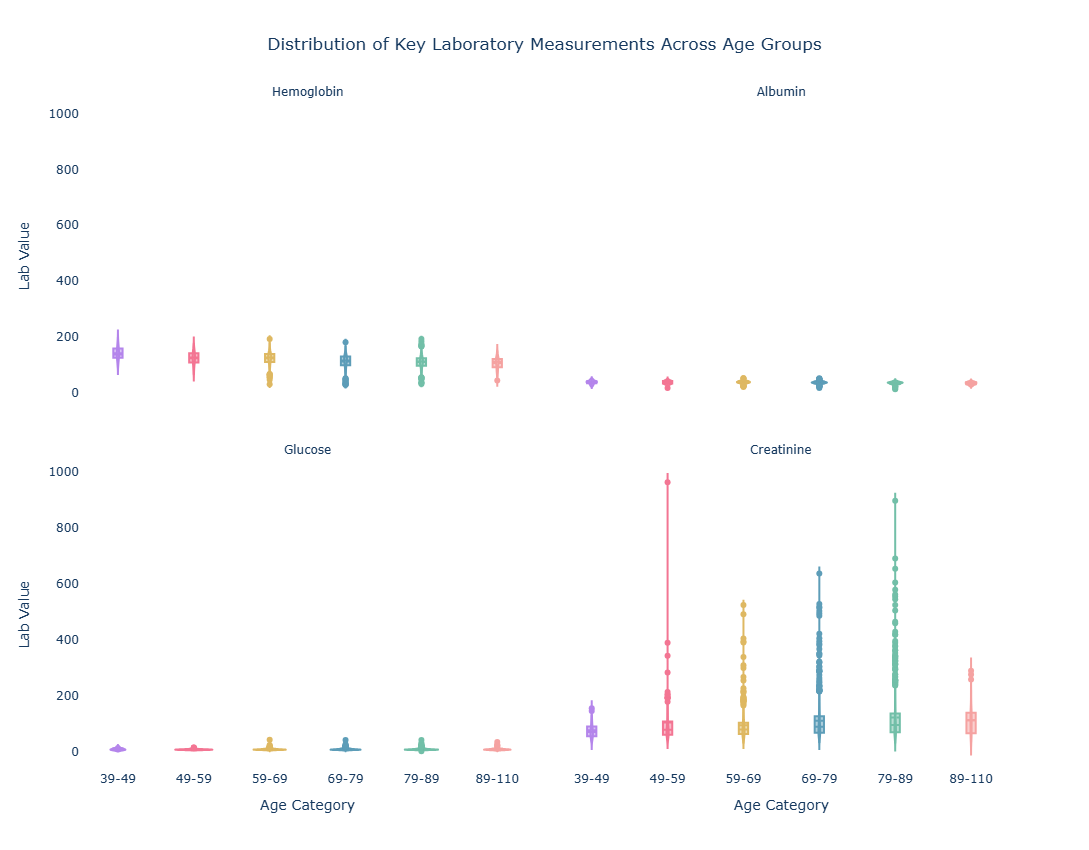


Actual Insight:

Creatinine showed the widest spread in the 89-110 age group. The median value was 110.90, and the middle 50% of values ranged from 64.40 to 138.10. This suggests that patients in this age group had more variation in creatinine than the other groups shown.


In [137]:
import pandas as pd
import numpy as np
import plotly.express as px
import re

# --------------------------------------------------
# 1. Select laboratory biomarkers
# --------------------------------------------------

lab_options = {
    "Hemoglobin": ["hemoglobin", "hemoglobin_blood_gas"],
    "Albumin": ["albumin", "albumin_serum"],
    "Glucose": ["glucose_blood_gas", "glucose"],
    "Creatinine": ["creatinine_enzymatic_method", "creatinine"]
}

selected_labs = {}

for label, options in lab_options.items():
    col = next((c for c in options if c in patient.columns), None)
    if col:
        selected_labs[label] = col

if len(selected_labs) < 2:
    raise ValueError("At least two laboratory biomarkers are required.")


# --------------------------------------------------
# 2. Prepare patient data
# --------------------------------------------------

tmp = patient[
    ["inpatient_number", "agecat"] + list(selected_labs.values())
].copy()

# Convert lab values to numeric
for col in selected_labs.values():
    tmp[col] = pd.to_numeric(tmp[col], errors="coerce")
    tmp[col] = tmp[col].replace([np.inf, -np.inf], np.nan)

# Remove rows missing inpatient ID or age category
tmp = tmp.dropna(subset=["inpatient_number", "agecat"])

# Keep one lab profile per inpatient number
tmp = (
    tmp.groupby("inpatient_number", as_index=False)
    .agg({
        "agecat": "first",
        **{col: "median" for col in selected_labs.values()}
    })
)

# Rename columns for readability
tmp = tmp.rename(
    columns={
        "agecat": "Age Category",
        **{col: label for label, col in selected_labs.items()}
    }
)

# --------------------------------------------------
# 3. Arrange age groups
# --------------------------------------------------

def age_sort_key(age):
    numbers = re.findall(r"\d+", str(age))
    return int(numbers[0]) if numbers else -1

tmp["Age Category"] = tmp["Age Category"].astype(str)

age_order = sorted(
    tmp["Age Category"].dropna().unique(),
    key=age_sort_key
)

# --------------------------------------------------
# 4. Convert to long format
# --------------------------------------------------

long_df = tmp.melt(
    id_vars=["inpatient_number", "Age Category"],
    value_vars=list(selected_labs.keys()),
    var_name="Biomarker",
    value_name="Lab Value"
)

long_df = long_df.dropna(subset=["Lab Value"])

# Keep only age groups with enough records
age_counts = (
    long_df.groupby(["Biomarker", "Age Category"], observed=True)
    .size()
    .reset_index(name="Patient Count")
)

valid_groups = age_counts[age_counts["Patient Count"] >= 20][
    ["Biomarker", "Age Category"]
]

long_df = long_df.merge(
    valid_groups,
    on=["Biomarker", "Age Category"],
    how="inner"
)

if long_df.empty:
    raise ValueError("Not enough data available for the violin chart.")


# --------------------------------------------------
# 5. Create violin chart
# --------------------------------------------------

color_map = {
    "21-29": "#3A86FF",
    "29-39": "#00A896",
    "39-49": "#9B5DE5",
    "49-59": "#EF476F",
    "59-69": "#D4A12E",
    "69-79": "#277DA1",
    "79-89": "#43AA8B",
    "89-110": "#F28482"
}

fig = px.violin(
    long_df,
    x="Age Category",
    y="Lab Value",
    color="Age Category",
    facet_col="Biomarker",
    facet_col_wrap=2,
    box=True,
    points="outliers",
    category_orders={"Age Category": age_order},
    color_discrete_map=color_map,
    title="Distribution of Key Laboratory Measurements Across Age Groups"
)

fig.update_traces(
    meanline_visible=True,
    opacity=0.75
)

fig.update_layout(
    height=850,
    title_x=0.5,
    paper_bgcolor="white",
    plot_bgcolor="white",
    font=dict(size=12, color="#16395F"),
    showlegend=False
)

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)

fig.for_each_annotation(
    lambda a: a.update(text=a.text.split("=")[-1])
)

fig.show()


# --------------------------------------------------
# 6. Generate actual insight
# --------------------------------------------------

summary = (
    long_df.groupby(["Biomarker", "Age Category"], observed=True)["Lab Value"]
    .agg(
        Median="median",
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75),
        Count="count"
    )
    .reset_index()
)

summary["IQR"] = summary["Q3"] - summary["Q1"]

# Keep groups with enough records
summary = summary[summary["Count"] >= 20]

if not summary.empty:
    top = summary.sort_values("IQR", ascending=False).iloc[0]

    print("\nActual Insight:\n")
    print(
        f"{top['Biomarker']} showed the widest spread in the "
        f"{top['Age Category']} age group. "
        f"The median value was {top['Median']:.2f}, and the middle 50% "
        f"of values ranged from {top['Q1']:.2f} to {top['Q3']:.2f}. "
        f"This suggests that patients in this age group had more variation "
        f"in {top['Biomarker'].lower()} than the other groups shown."
    )
else:
    print("Not enough age groups had enough records to generate an insight.")

## Actual Insight

The violin chart highlights differences in laboratory measurements across age groups. Some groups may show a wider spread of values, while others have measurements concentrated within a smaller range. These patterns help us understand how laboratory profiles vary with age and identify measurements that may need further investigation.

### PA10: Which patient groups at hospital discharge, based on their demographic, cardiac, comorbidity, laboratory, neurological, respiratory, hospital stay, and medication characteristics, have higher rates of readmission or emergency department return, and which groups may need enhanced discharge planning and earlier follow-up?

### Type of Analysis
Prescriptive Analysis: Clustered Heatmap with Dendrogram and Post-Discharge Outcome Bar Chart
### Reasoning
This prescriptive analysis groups patients with similar discharge characteristics and compares their readmission and ED-return patterns to identify groups that may benefit from closer follow-up and enhanced discharge planning.

In [144]:

# ============================================================
# 1. IMPORTS AND FILE SETUP
# ============================================================

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

# ------------------------------------------------------------
# File resolver:
# The notebook works if the CSV files are either:
#   1) in the same folder as this notebook, OR
#   2) in /mnt/data (ChatGPT environment).
# ------------------------------------------------------------

# Define the main project folder
project_folder = Path(
    r"C:\Users\swith\OneDrive\Desktop\Swithi\Numpy Ninja\Python Hackathon Sept 2026\Python_Hackathon_Sep_2026\cardiac_failure\__Final_Cleaned Dataset"
)

# Define CSV filenames


FILES = {
    "cardiac": "Team7_CodeAvengers_Category1_DataCleaning_cardiac_complications.csv",
    "demography": "Team7_CodeAvengers_Category1_DataCleaning_demography.csv",
    "hospital": "Team7_CodeAvengers_Category1_DataCleaning_hospitalization_discharge.csv", 
    "labs": "Team7_CodeAvengers_Category1_DataCleaning_labs.csv",
    "prescriptions": "Team7_CodeAvengers_Category1_DataCleaning_patient_precriptions.csv",
    "history": "Team7_CodeAvengers_Category1_DataCleaning_patienthistory_cleaned.csv",
    "responsiveness": "Team7_CodeAvengers_Category1_DataCleaning_responsivenes.csv"
    }


In [145]:

# ============================================================
# 2. LOAD ALL CLEANED DATASETS
# ============================================================


# Read the cleaned datasets
cardiac = pd.read_csv(project_folder / FILES["cardiac"])
demography = pd.read_csv(project_folder / FILES["demography"])
hospital = pd.read_csv(project_folder / FILES["hospital"])
labs = pd.read_csv(project_folder / FILES["labs"])
prescriptions = pd.read_csv(project_folder / FILES["prescriptions"])
history = pd.read_csv(project_folder / FILES["history"])
responsiveness = pd.read_csv(project_folder / FILES["responsiveness"])

datasets = {
    "Cardiac": cardiac,
    "Demography": demography,
    "Hospitalization/Discharge": hospital,
    "Labs": labs,
    "Prescriptions": prescriptions,
    "Patient History": history,
    "Responsiveness": responsiveness
}

print("Dataset dimensions")
for name, df in datasets.items():
    print(f"{name:25s}: {df.shape[0]:5d} rows x {df.shape[1]:3d} columns")

# Confirm merge key
for name, df in datasets.items():
    if "inpatient_number" not in df.columns:
        raise KeyError(f"'inpatient_number' is missing from {name}.")


Dataset dimensions
Cardiac                  :  2008 rows x  14 columns
Demography               :  2008 rows x   7 columns
Hospitalization/Discharge:  2008 rows x  21 columns
Labs                     :  2008 rows x 107 columns
Prescriptions            : 15362 rows x   2 columns
Patient History          :  2008 rows x  17 columns
Responsiveness           :  2008 rows x   6 columns


In [146]:

# ============================================================
# 3. AGGREGATE PRESCRIPTIONS TO ONE ROW PER PATIENT
# ============================================================

# Prescription data contains multiple rows per patient.
# Convert it into patient-level medication burden before merging.
rx_agg = (
    prescriptions
    .groupby("inpatient_number", as_index=False)
    .agg(
        medication_count=("drug_name", "size"),
        unique_medications=("drug_name", "nunique")
    )
)

print("Prescription records:", len(prescriptions))
print("Patients with prescription records:", rx_agg["inpatient_number"].nunique())


Prescription records: 15362
Patients with prescription records: 2007


In [147]:

# ============================================================
# 4. MERGE ALL SEVEN DATA SOURCES
# ============================================================

merged = (
    demography
    .merge(cardiac, on="inpatient_number", how="inner")
    .merge(history, on="inpatient_number", how="inner")
    .merge(labs, on="inpatient_number", how="inner")
    .merge(responsiveness, on="inpatient_number", how="inner")
    .merge(hospital, on="inpatient_number", how="inner")
    .merge(rx_agg, on="inpatient_number", how="left")
)

merged[["medication_count", "unique_medications"]] = (
    merged[["medication_count", "unique_medications"]].fillna(0)
)

print("Merged patient-level dataset:", merged.shape)
print("Unique patients:", merged["inpatient_number"].nunique())


Merged patient-level dataset: (2008, 169)
Unique patients: 2008


In [148]:

# ============================================================
# 5. DERIVE ANALYSIS VARIABLES
# ============================================================

# Approximate numeric age from the provided age categories.
# This preserves the dataset's existing categorization while allowing clustering.
age_midpoint_map = {
    "21-29": 25.0,
    "29-39": 34.0,
    "39-49": 44.0,
    "49-59": 54.0,
    "59-69": 64.0,
    "69-79": 74.0,
    "79-89": 84.0,
    "89-110": 99.5
}
merged["age_midpoint"] = merged["agecat"].map(age_midpoint_map)

# Respiratory-support indicators
merged["imv_flag"] = (
    merged["respiratory_support"].astype(str).str.upper().eq("IMV")
).astype(int)

merged["oxygen_therapy_flag"] = (
    merged["oxygen_inhalation"].astype(str).str.lower().str.contains("oxygen")
).astype(int)

# Comorbidity count across available binary history indicators
comorbidity_columns = [
    "cerebrovascular_disease",
    "dementia",
    "chronic_obstructive_pulmonary_disease",
    "connective_tissue_disease",
    "peptic_ulcer_disease",
    "diabetes",
    "moderate_to_severe_chronic_kidney_disease",
    "hemiplegia",
    "malignant_lymphoma",
    "solid_tumor",
    "liver_disease",
    "aids",
    "acute_renal_failure"
]

merged["comorbidity_count"] = (
    merged[comorbidity_columns]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .sum(axis=1)
)

# Primary prescriptive outcome:
# 1 if the patient had either 6-month readmission OR 6-month ED return.
merged["post_discharge_utilization_6m"] = (
    merged[
        [
            "re_admission_within_6_months",
            "return_to_emergency_department_within_6_months"
        ]
    ]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .max(axis=1)
    .astype(int)
)

# Restrict to patients who reached a discharge state rather than dying in hospital.
analysis_df = merged[
    (merged["outcome_during_hospitalization"].astype(str) != "Dead") &
    (merged["destinationdischarge"].astype(str) != "Died")
].copy()

print("Patients in discharge analysis cohort:", len(analysis_df))
print(
    "6-month readmission/ED-utilization rate:",
    f"{analysis_df['post_discharge_utilization_6m'].mean():.1%}"
)


Patients in discharge analysis cohort: 1992
6-month readmission/ED-utilization rate: 39.2%


In [149]:

# ============================================================
# 6. SELECT MULTIDOMAIN CLINICAL FEATURES
# ============================================================

# These features intentionally cover every domain in the selected question.
# Outcome variables are NOT included in clustering.

FEATURES = [
    # Demographics
    "age_midpoint",
    "bmi",

    # Cardiac status
    "nyha_cardiac_function_classification",
    "killip_grade",
    "myocardial_infarction",
    "congestive_heart_failure",

    # Comorbidity burden
    "cci_score",
    "comorbidity_count",
    "moderate_to_severe_chronic_kidney_disease",
    "diabetes",
    "acute_renal_failure",

    # Laboratory / physiologic status
    "glomerular_filtration_rate",
    "creatinine_enzymatic_method",
    "urea",
    "brain_natriuretic_peptide",
    "high_sensitivity_troponin",
    "sodium",
    "potassium",
    "hemoglobin",
    "albumin",

    # Neurological responsiveness
    "gcs",

    # Respiratory support
    "imv_flag",
    "oxygen_therapy_flag",

    # Hospital course
    "dischargeday",

    # Medication burden
    "unique_medications"
]

DISPLAY_LABELS = {
    "age_midpoint": "Age",
    "bmi": "BMI",
    "nyha_cardiac_function_classification": "NYHA class",
    "killip_grade": "Killip grade",
    "myocardial_infarction": "MI",
    "congestive_heart_failure": "CHF",
    "cci_score": "CCI score",
    "comorbidity_count": "Comorbidity count",
    "moderate_to_severe_chronic_kidney_disease": "CKD",
    "diabetes": "Diabetes",
    "acute_renal_failure": "Acute renal failure",
    "glomerular_filtration_rate": "eGFR",
    "creatinine_enzymatic_method": "Creatinine",
    "urea": "Urea",
    "brain_natriuretic_peptide": "BNP",
    "high_sensitivity_troponin": "hs-Troponin",
    "sodium": "Sodium",
    "potassium": "Potassium",
    "hemoglobin": "Hemoglobin",
    "albumin": "Albumin",
    "gcs": "GCS",
    "imv_flag": "Invasive ventilation",
    "oxygen_therapy_flag": "Oxygen therapy",
    "dischargeday": "Length of stay",
    "unique_medications": "Medication burden"
}

missing = (
    analysis_df[FEATURES]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("Highest missingness among selected clustering variables:")
display(missing.head(10).round(2).to_frame("Missing %"))

# LVEF is intentionally not used because this cleaned file contains substantial
# missingness in that variable; NYHA/Killip/MI/CHF still represent cardiac status.


Highest missingness among selected clustering variables:


,Missing %
albumin,4.970
high_sensitivity_troponin,3.820
glomerular_filtration_rate,3.060
brain_natriuretic_peptide,1.660
hemoglobin,1.310
creatinine_enzymatic_method,1.050
urea,1.050
potassium,0.450
sodium,0.450
cci_score,0.250


In [150]:

# ============================================================
# 7. PREPROCESS FOR HIERARCHICAL CLUSTERING
# ============================================================

X = analysis_df[FEATURES].copy()

# Reduce the influence of extreme right-skew in selected positive-valued variables.
LOG_TRANSFORM = [
    "creatinine_enzymatic_method",
    "urea",
    "brain_natriuretic_peptide",
    "high_sensitivity_troponin",
    "dischargeday",
    "unique_medications"
]

for col in LOG_TRANSFORM:
    X[col] = np.log1p(pd.to_numeric(X[col], errors="coerce").clip(lower=0))

# Median imputation is used only for the selected clustering features.
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

# Robust scaling is useful for clinical data because it limits the influence
# of extreme outliers while preserving relative patient differences.
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Prevent a very small number of extreme values from dominating Euclidean distance.
X_scaled = np.clip(X_scaled, -5, 5)

# Hierarchical Ward linkage
patient_linkage = linkage(X_scaled, method="ward", metric="euclidean")

# Compare a small, clinically interpretable cluster range.
silhouette_results = {}
for k in range(3, 7):
    labels_k = fcluster(patient_linkage, t=k, criterion="maxclust")
    silhouette_results[k] = silhouette_score(X_scaled, labels_k)

silhouette_table = (
    pd.DataFrame.from_dict(
        silhouette_results,
        orient="index",
        columns=["Silhouette Score"]
    )
    .rename_axis("Number of patient groups")
)

display(silhouette_table.round(3))

# Four patient groups are retained for this analysis.
# This preserves a clinically distinct neurologic/respiratory high-acuity group
# while keeping the final figure readable for presentation.
N_CLUSTERS = 4

analysis_df["patient_group"] = fcluster(
    patient_linkage,
    t=N_CLUSTERS,
    criterion="maxclust"
)


,Silhouette Score
Number of patient groups,
3,0.164
4,0.159
5,0.061
6,0.037


In [151]:

# ============================================================
# 8. CREATE CLUSTER-LEVEL CLINICAL AND OUTCOME SUMMARY
# ============================================================

summary = (
    analysis_df
    .groupby("patient_group")
    .agg(
        n=("inpatient_number", "size"),
        age_mean=("age_midpoint", "mean"),
        nyha_mean=("nyha_cardiac_function_classification", "mean"),
        killip_mean=("killip_grade", "mean"),
        cci_mean=("cci_score", "mean"),
        egfr_mean=("glomerular_filtration_rate", "mean"),
        creatinine_mean=("creatinine_enzymatic_method", "mean"),
        bnp_median=("brain_natriuretic_peptide", "median"),
        troponin_median=("high_sensitivity_troponin", "median"),
        gcs_mean=("gcs", "mean"),
        imv_rate=("imv_flag", "mean"),
        los_mean=("dischargeday", "mean"),
        medication_mean=("unique_medications", "mean"),
        readmit_28d=("re_admission_within_28_days", "mean"),
        readmit_3m=("re_admission_within_3_months", "mean"),
        readmit_6m=("re_admission_within_6_months", "mean"),
        ed_6m=("return_to_emergency_department_within_6_months", "mean"),
        utilization_6m=("post_discharge_utilization_6m", "mean"),
        death_6m=("death_within_6_months", "mean")
    )
)

percentage_cols = [
    "imv_rate",
    "readmit_28d",
    "readmit_3m",
    "readmit_6m",
    "ed_6m",
    "utilization_6m",
    "death_6m"
]

summary_display = summary.copy()
summary_display[percentage_cols] = summary_display[percentage_cols] * 100

summary_display = summary_display.rename(columns={
    "n": "Patients",
    "age_mean": "Mean age",
    "nyha_mean": "Mean NYHA",
    "killip_mean": "Mean Killip",
    "cci_mean": "Mean CCI",
    "egfr_mean": "Mean eGFR",
    "creatinine_mean": "Mean creatinine",
    "bnp_median": "Median BNP",
    "troponin_median": "Median hs-Troponin",
    "gcs_mean": "Mean GCS",
    "imv_rate": "IMV %",
    "los_mean": "Mean LOS",
    "medication_mean": "Mean medication burden",
    "readmit_28d": "28-day readmission %",
    "readmit_3m": "3-month readmission %",
    "readmit_6m": "6-month readmission %",
    "ed_6m": "6-month ED return %",
    "utilization_6m": "6-month readmission/ED %",
    "death_6m": "6-month death %"
})

display(summary_display.round(2))


,Patients,Mean age,Mean NYHA,Mean Killip,Mean CCI,Mean eGFR,Mean creatinine,Median BNP,Median hs-Troponin,Mean GCS,IMV %,Mean LOS,Mean medication burden,28-day readmission %,3-month readmission %,6-month readmission %,6-month ED return %,6-month readmission/ED %,6-month death %
patient_group,,,,,,,,,,,,,,,,,,,
1,1364,73.950,3.070,1.940,1.620,79.200,83.030,629.490,0.040,15.000,0.000,7.790,7.500,5.870,21.410,35.780,35.950,36.220,1.390
2,137,73.260,3.350,2.110,2.290,58.530,147.330,"1,906.090",0.890,14.940,0.730,8.630,8.510,9.490,24.090,34.310,35.040,35.040,4.380
3,39,76.710,3.620,2.850,1.770,48.580,173.490,"1,150.920",0.130,8.740,48.720,9.360,7.130,2.560,23.080,35.900,35.900,35.900,17.950
4,452,76.040,3.180,2.010,2.440,42.600,167.030,932.760,0.080,14.970,0.220,14.450,7.920,10.180,36.280,49.560,49.340,49.780,3.100


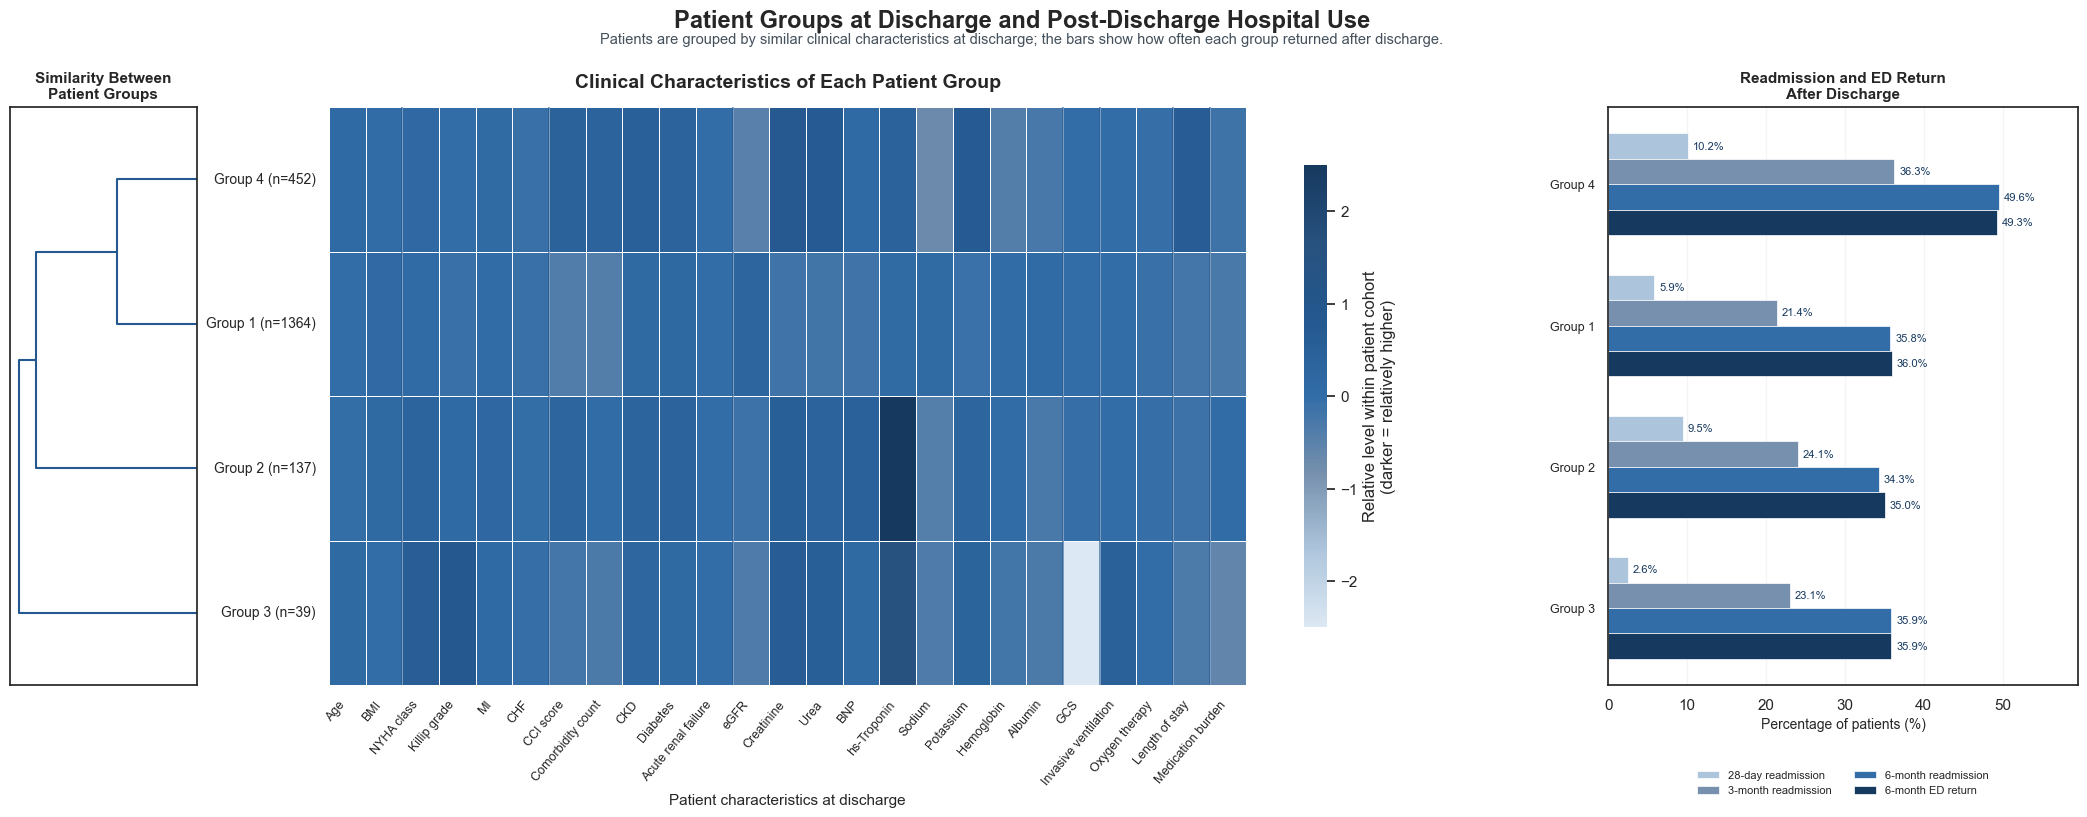

Figure saved as: Patient_Groups_Heatmap_Dendrogram.png


In [152]:

# ============================================================
# 9. CLUSTERED HEATMAP + DENDROGRAM + OUTCOME PANEL
# ============================================================

# Build robust-standardized patient-group profiles.
scaled_df = pd.DataFrame(
    X_scaled,
    columns=FEATURES,
    index=analysis_df.index
)
scaled_df["patient_group"] = analysis_df["patient_group"].values

profile_matrix = (
    scaled_df
    .groupby("patient_group")[FEATURES]
    .mean()
)

# Use group-level clinical profiles to create the dendrogram.
profile_linkage = linkage(
    profile_matrix.values,
    method="ward",
    metric="euclidean"
)

# Get the dendrogram order.
# For a left-oriented dendrogram, scipy returns leaves bottom-to-top,
# so we reverse the order for top-to-bottom display in the heatmap.
dendro_info = dendrogram(
    profile_linkage,
    labels=[f"Group {i}" for i in profile_matrix.index],
    orientation="left",
    no_plot=True
)

bottom_to_top_clusters = [
    int(label.split()[-1]) for label in dendro_info["ivl"]
]
display_clusters = bottom_to_top_clusters[::-1]

# Heatmap data in the same top-to-bottom order as the plotted dendrogram.
profile_plot = profile_matrix.loc[display_clusters].copy()
profile_plot.columns = [DISPLAY_LABELS[c] for c in profile_plot.columns]
profile_plot.index = [
    f"Group {cluster} (n={int(summary.loc[cluster, 'n'])})"
    for cluster in display_clusters
]

# Outcome panel in the same group order.
outcome_plot = (
    summary.loc[
        display_clusters,
        ["readmit_28d", "readmit_3m", "readmit_6m", "ed_6m"]
    ]
    * 100
)

outcome_plot.columns = [
    "28-day readmission",
    "3-month readmission",
    "6-month readmission",
    "6-month ED return"
]

# ------------------------------------------------------------
# COLOR PALETTES
# ------------------------------------------------------------

# Muted clinical blue palette for the heatmap.
clinical_blues = LinearSegmentedColormap.from_list(
    "clinical_blues",
    [
        "#DCE8F3",   # very light muted blue
        "#ADC5DC",   # light steel blue
        "#7690AD",   # soft blue-gray
        "#326DA7",   # medium clinical blue
        "#24588F",   # darker clinical blue
        "#27517E",   # deep slate blue
        "#16395F"    # dark navy
    ]
)

# Matching shades for the outcome bars.
# Lighter to darker shades make the time progression easier to follow.
outcome_colors = [
    "#ADC5DC",   # 28-day readmission
    "#7690AD",   # 3-month readmission
    "#326DA7",   # 6-month readmission
    "#16395F"    # 6-month ED return
]

# ------------------------------------------------------------
# FIGURE LAYOUT
# ------------------------------------------------------------

fig = plt.figure(figsize=(22, 8.5))

gs = fig.add_gridspec(
    nrows=1,
    ncols=3,
    width_ratios=[1.35, 8.3, 3.4],
    wspace=0.22
)

# ------------------------------------------------------------
# LEFT: DENDROGRAM
# ------------------------------------------------------------

ax_d = fig.add_subplot(gs[0, 0])

dendrogram(
    profile_linkage,
    orientation="left",
    no_labels=True,                     # avoids duplicate/overlapping labels
    color_threshold=0,
    above_threshold_color="#24588F",
    ax=ax_d
)

ax_d.set_title(
    "Similarity Between\nPatient Groups",
    fontsize=11,
    weight="bold"
)
ax_d.set_xlabel("")
ax_d.set_ylabel("")
ax_d.tick_params(axis="x", bottom=False, labelbottom=False)
ax_d.tick_params(axis="y", left=False, labelleft=False)

# ------------------------------------------------------------
# MIDDLE: HEATMAP
# ------------------------------------------------------------

ax_h = fig.add_subplot(gs[0, 1])

sns.heatmap(
    profile_plot,
    cmap=clinical_blues,
    center=0,
    vmin=-2.5,
    vmax=2.5,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label": "Relative level within patient cohort\n(darker = relatively higher)",
        "shrink": 0.80
    },
    ax=ax_h
)

ax_h.set_title(
    "Clinical Characteristics of Each Patient Group",
    fontsize=14,
    weight="bold",
    pad=14
)

ax_h.set_xlabel(
    "Patient characteristics at discharge",
    fontsize=11
)
ax_h.set_ylabel("")

ax_h.tick_params(
    axis="x",
    labelrotation=50,
    labelsize=9
)

# Right-align x-axis labels for easier reading.
for label in ax_h.get_xticklabels():
    label.set_horizontalalignment("right")

ax_h.tick_params(
    axis="y",
    labelrotation=0,
    labelsize=10
)

# Add visual separators between clinical domains.
# Demographics 2 | Cardiac 4 | Comorbidity 5 | Labs 9 |
# Neurologic 1 | Respiratory 2 | Hospital course 1 | Medication 1
domain_breaks = [2, 6, 11, 20, 21, 23, 24]

for x in domain_breaks:
    ax_h.axvline(
        x,
        linewidth=1.2,
        color="#24588F",
        alpha=0.70
    )

# ------------------------------------------------------------
# RIGHT: POST-DISCHARGE OUTCOME PANEL
# ------------------------------------------------------------

ax_o = fig.add_subplot(gs[0, 2])

y = np.arange(len(display_clusters))
bar_height = 0.18

for j, col in enumerate(outcome_plot.columns):
    bars = ax_o.barh(
        y + (j - 1.5) * bar_height,
        outcome_plot[col].values,
        height=bar_height,
        label=col,
        color=outcome_colors[j],
        edgecolor="white",
        linewidth=0.5
    )

    # Add percentage values at the end of each bar.
    for bar in bars:
        width = bar.get_width()
        ax_o.text(
            width + 0.6,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.1f}%",
            va="center",
            fontsize=8,
            color="#16395F"
        )

ax_o.set_yticks(y)

ax_o.set_yticklabels(
    [f"Group {c}" for c in display_clusters],
    fontsize=9
)

# Make Group 1st row appear at the top, matching the heatmap order.
ax_o.invert_yaxis()

ax_o.set_xlabel(
    "Percentage of patients (%)",
    fontsize=10
)

ax_o.set_title(
    "Readmission and ED Return\nAfter Discharge",
    fontsize=11,
    weight="bold"
)

# Leave a little extra room for the percentage labels.
max_outcome = outcome_plot.to_numpy().max()
ax_o.set_xlim(0, min(100, max_outcome + 10))

ax_o.grid(
    axis="x",
    alpha=0.20
)

# Put the legend below the plot so it does not cover any bars.
ax_o.legend(
    fontsize=8,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.13),
    ncol=2,
    frameon=False
)

# ------------------------------------------------------------
# OVERALL TITLE + EXPLANATORY SUBTITLE
# ------------------------------------------------------------

fig.suptitle(
    "Patient Groups at Discharge and Post-Discharge Hospital Use",
    fontsize=17,
    weight="bold",
    y=0.995
)

fig.text(
    0.5,
    0.955,
    "Patients are grouped by similar clinical characteristics at discharge; "
    "the bars show how often each group returned after discharge.",
    ha="center",
    fontsize=10.5,
    color="#44515C"
)

# Manual spacing works better than tight_layout for this multi-panel figure.
fig.subplots_adjust(
    left=0.04,
    right=0.98,
    top=0.88,
    bottom=0.20,
    wspace=0.22
)

OUTPUT_FIGURE = "Patient_Groups_Heatmap_Dendrogram.png"

plt.savefig(
    OUTPUT_FIGURE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved as: {OUTPUT_FIGURE}")


### Actual Insight
The analysis identified four patient groups with distinct clinical characteristics and post-discharge outcomes. Group 4 (452 patients) showed the highest hospital utilization, with 49.6% readmitted and 49.3% returning to the emergency department within six months. This group was characterized by greater comorbidity burden, reduced kidney function, and longer hospital stays. In comparison, Groups 1, 2, and 3 had approximately 34–36% six-month readmission rates. These findings suggest that patients with multiple comorbidities, renal impairment, and prolonged hospitalization may benefit from enhanced discharge planning, medication review, closer clinical monitoring, and earlier post-discharge follow-up.

## Additional Questions

### DA15. How do systolic and diastolic blood pressure vary across age categories?
**Analysis type:** Descriptive — Vital sign × age

**Question**  
DA15. How do systolic and diastolic blood pressure vary across age categories?

**Reasoning**  

Blood pressure is more complete than many specialized labs and provides a useful age-based physiologic comparison.


**Answer**  
Run/read the executed code and chart below.

In [18]:
bp = (
    patient.groupby("agecat", observed=True)[
        ["systolic_blood_pressure","diastolic_blood_pressure"]
    ].median().reset_index()
)
bp_long = bp.melt("agecat", var_name="measure", value_name="median_value")
fig = px.line(
    bp_long, x="agecat", y="median_value", color="measure", markers=True,
    title="Median Blood Pressure by Age Category",
    labels={"agecat":"Age Category", "median_value":"Median Value", "measure":"Measure"}
)
fig.show()
display(bp.round(2))

,agecat,systolic_blood_pressure,diastolic_blood_pressure
0,21-29,102.500,75.000
1,29-39,114.000,79.000
2,39-49,120.000,71.500
3,49-59,123.000,74.000
4,59-69,124.000,76.000
5,69-79,130.000,76.000
6,79-89,134.000,78.000
7,89-110,142.000,80.000


**Actual Insight**  

Viewing both pressure components on the same age axis gives a more complete blood-pressure profile than charting a single measure.

### DA16. Which selected lab variables are most strongly correlated?
**Analysis type:** Descriptive / Diagnostic — Correlation heat map

**Question**  
DA16. Which selected lab variables are most strongly correlated?

**Reasoning**  

A targeted Spearman heat map is more interpretable than correlating every column. It focuses on major renal, hematologic, cardiac, metabolic and vital-sign variables.


**Answer**  
Run/read the executed code and chart below.

In [19]:
corr_cols = [
    "pulse","systolic_blood_pressure","diastolic_blood_pressure",
    "creatinine_enzymatic_method","urea","uric_acid",
    "glomerular_filtration_rate","white_blood_cell","hemoglobin","platelet",
    "high_sensitivity_troponin","brain_natriuretic_peptide",
    "albumin","glucose_blood_gas","lactate","oxygen_saturation"
]
corr = patient[corr_cols].corr(method="spearman")

fig = px.imshow(
    corr, zmin=-1, zmax=1, aspect="auto",
    title="Spearman Correlation Heat Map — Selected Lab Variables",
    labels={"color":"Spearman ρ"}
)
fig.update_layout(height=800)
fig.show()

**Actual Insight**  

The heat map quickly separates strong lab relationships from weak ones and is useful for deciding which scatter plots or multivariable analyses deserve deeper attention. Correlation is association, not causation.

### DA17. What are the strongest pairwise correlations among the selected labs?
**Analysis type:** Descriptive / Diagnostic — Ranked relationships

**Question**  
DA17. What are the strongest pairwise correlations among the selected labs?

**Reasoning**  

The heat map is visual; this question converts it into a ranked table and also reports the number of complete pairs supporting each correlation.


**Answer**  
Run/read the executed code and chart below.

In [20]:
pairs = []
for i,a in enumerate(corr.columns):
    for b in corr.columns[i+1:]:
        pair_n = patient[[a,b]].dropna().shape[0]
        pairs.append({
            "variable_1":a,
            "variable_2":b,
            "rho":corr.loc[a,b],
            "abs_rho":abs(corr.loc[a,b]),
            "complete_pairs":pair_n
        })

pair_df = pd.DataFrame(pairs).sort_values("abs_rho", ascending=False)
display(pair_df.head(20).round(3))

,variable_1,variable_2,rho,abs_rho,complete_pairs
44,creatinine_enzymatic_method,glomerular_filtration_rate,-0.944,0.944,1945
42,creatinine_enzymatic_method,urea,0.687,0.687,1985
55,urea,glomerular_filtration_rate,-0.669,0.669,1945
15,systolic_blood_pressure,diastolic_blood_pressure,0.627,0.627,2008
43,creatinine_enzymatic_method,uric_acid,0.590,0.590,1985
54,urea,uric_acid,0.568,0.568,1985
105,high_sensitivity_troponin,brain_natriuretic_peptide,0.530,0.530,1916
65,uric_acid,glomerular_filtration_rate,-0.519,0.519,1945
73,uric_acid,lactate,0.413,0.413,989
90,white_blood_cell,lactate,0.351,0.351,985


**Actual Insight**  

Ranking correlations prevents visually striking but weak relationships from receiving too much attention. Complete-pair counts help distinguish stable findings from correlations supported by sparse data.

### DA18. What is the unique medication burden per patient?
**Analysis type:** Descriptive — Prescription burden

**Question**  
DA18. What is the unique medication burden per patient?

**Reasoning**  

The prescription table has multiple rows per patient. Counting unique drug names converts it into a patient-level medication-burden measure without treating repeated entries as separate medications.


**Answer**  
Run/read the executed code and chart below.

In [21]:
fig = px.histogram(
    patient, x="unique_medication_count", nbins=18,
    title="Distribution of Unique Medications per Patient",
    labels={"unique_medication_count":"Unique Medications per Patient"}
)
fig.show()

display(patient["unique_medication_count"].describe().round(2).to_frame("value"))

,value
count,"2,008.000"
mean,7.650
std,2.430
min,0.000
25%,6.000
50%,8.000
75%,9.000
max,16.000


**Actual Insight**  

Medication burden is substantial in this cohort. The distribution gives a defensible, data-driven basis for defining higher medication burden using a percentile rather than an arbitrary number.

### DA19. How does medication burden vary across age categories?
**Analysis type:** Descriptive — Prescription × age

**Question**  
DA19. How does medication burden vary across age categories?

**Reasoning**  

This directly connects the prescription dataset with the most useful demographic grouping. Medians are emphasized because medication counts are discrete and can be skewed.


**Answer**  
Run/read the executed code and chart below.

In [22]:
med_age = (
    patient.groupby("agecat", observed=True)["unique_medication_count"]
           .agg(["count","mean","median"])
           .reset_index()
)
fig = px.line(
    med_age, x="agecat", y="median", markers=True,
    title="Median Unique Medication Count by Age Category",
    labels={"agecat":"Age Category", "median":"Median Unique Medication Count"}
)
fig.show()
display(med_age.round(2))

,agecat,count,mean,median
0,21-29,4,8.250,8.500
1,29-39,12,6.750,7.500
2,39-49,56,8.040,8.000
3,49-59,106,7.430,7.500
4,59-69,368,7.890,8.000
5,69-79,715,7.920,8.000
6,79-89,646,7.370,7.000
7,89-110,101,6.730,7.000


**Actual Insight**  

This chart shows whether higher medication burden is concentrated in particular age bands and is more informative than a medication-count histogram alone.

### DA20. Does medication burden differ by gender?
**Analysis type:** Descriptive — Prescription × gender

**Question**  
DA20. Does medication burden differ by gender?

**Reasoning**  

Gender is used as a simple supporting segmentation variable to check whether the patient-level medication count differs across groups.


**Answer**  
Run/read the executed code and chart below.

In [23]:
fig = px.box(
    patient, x="gender", y="unique_medication_count", points="outliers",
    title="Unique Medication Count by Gender"
)
fig.show()

display(
    patient.groupby("gender")["unique_medication_count"]
           .agg(["count","mean","median"])
           .round(2)
)

,count,mean,median
gender,,,
Female,1163,7.440,8.000
Male,845,7.940,8.000


**Actual Insight**  

A gender-stratified view adds context to the overall medication-burden distribution while keeping the prescription dataset at the center of the analysis.

### DA21. Which medications are most prevalent across unique patients?
**Analysis type:** Descriptive — Prescription prevalence

**Question**  
DA21. Which medications are most prevalent across unique patients?

**Reasoning**  

Raw prescription-row counts can overstate repeated entries. Patient-level prevalence answers a more meaningful question: how many unique patients received each drug?


**Answer**  
Run/read the executed code and chart below.

In [24]:
rx_unique = rx.drop_duplicates(["inpatient_number","drug_name"])
drug_prev = (
    rx_unique.groupby("drug_name")["inpatient_number"]
             .nunique()
             .sort_values(ascending=False)
)
drug_prev_pct = drug_prev / patient["inpatient_number"].nunique() * 100

top20 = pd.DataFrame({
    "drug_name":drug_prev.head(20).index,
    "patients":drug_prev.head(20).values,
    "prevalence_pct":drug_prev_pct.head(20).values
}).sort_values("patients")

fig = px.bar(
    top20, x="patients", y="drug_name", orientation="h",
    hover_data=["prevalence_pct"],
    title="Top 20 Medications by Unique-Patient Prevalence"
)
fig.show()

display(top20.sort_values("patients", ascending=False).round(1))

,drug_name,patients,prevalence_pct
0,Spironolactone tablet,1833,91.300
1,Furosemide injection,1718,85.600
2,Furosemide tablet,1641,81.700
3,Meglumine Adenosine Cyclophosphate for injection,1114,55.500
4,Deslanoside injection,1015,50.500
5,Digoxin tablet,998,49.700
6,Aspirin enteric-coated tablet,958,47.700
7,Atorvastatin calcium tablet,822,40.900
8,Milrinone injection,707,35.200
9,Sulfotanshinone sodium injection,570,28.400


**Actual Insight**  

Patient-level prevalence is the correct descriptive metric for common-medication analysis. It avoids giving extra weight to duplicate prescription rows for the same patient and drug.

### DA22. How does prevalence of the most common medications vary by age category?
**Analysis type:** Descriptive — Prescription × age heat map

**Question**  
DA22. How does prevalence of the most common medications vary by age category?

**Reasoning**  

A heat map can compare several medications and age categories simultaneously. Percent prevalence is used instead of raw counts so age groups with different sizes can be compared fairly.


**Answer**  
Run/read the executed code and chart below.

In [25]:
top_drugs = drug_prev.head(12).index.tolist()
age_med = med_usage_by_group("agecat", top_drugs).reindex(AGE_ORDER)

fig = px.imshow(
    age_med.T, aspect="auto", text_auto=".0f",
    title="Medication Prevalence by Age Category (%)",
    labels={"x":"Age Category", "y":"Medication", "color":"Prevalence %"}
)
fig.show()
display(age_med.round(1))

drug_name,Aspirin enteric-coated tablet,Atorvastatin calcium tablet,Benazepril hydrochloride tablet,Deslanoside injection,Digoxin tablet,Furosemide injection,Furosemide tablet,Meglumine Adenosine Cyclophosphate for injection,Metoprolol Succinate Sustained-release tablet,Milrinone injection,Spironolactone tablet,Sulfotanshinone sodium injection
agecat,,,,,,,,,,,,
21-29,25.000,0.000,25.000,100.000,100.000,100.000,100.000,75.000,75.000,50.000,100.000,0.000
29-39,8.300,16.700,33.300,58.300,50.000,91.700,91.700,58.300,50.000,41.700,91.700,16.700
39-49,28.600,19.600,46.400,62.500,73.200,89.300,87.500,57.100,50.000,33.900,98.200,23.200
49-59,35.800,19.800,28.300,59.400,56.600,84.900,82.100,50.000,34.900,39.600,94.300,20.800
59-69,42.700,33.700,24.200,55.400,55.200,86.700,83.200,58.400,35.300,37.200,93.800,28.300
69-79,51.200,41.100,23.600,52.300,53.100,87.400,82.200,54.100,27.700,39.300,93.300,27.400
79-89,52.300,48.900,16.300,43.800,41.600,83.400,80.500,56.300,17.300,31.900,87.500,31.000
89-110,40.600,53.500,9.900,44.600,34.700,79.200,75.200,52.500,8.900,14.900,85.100,32.700


**Actual Insight**  

The heat map identifies medications that remain common across age bands and medications whose prevalence is concentrated in specific groups. Very small age categories still require denominator caution.

### DA23. How does prevalence of the most common medications vary by gender?
**Analysis type:** Descriptive — Prescription × gender

**Question**  
DA23. How does prevalence of the most common medications vary by gender?

**Reasoning**  

The same patient-level prevalence logic can be used to compare medication exposure across gender groups without being distorted by the different numbers of patients in each group.


**Answer**  
Run/read the executed code and chart below.

In [26]:
top10 = drug_prev.head(10).index.tolist()
gender_med =  med_usage_by_group("gender", top10).reset_index()
long = gender_med.melt("gender", var_name="drug_name", value_name="prevalence_pct")

fig = px.bar(
    long, x="drug_name", y="prevalence_pct", color="gender",
    barmode="group",
    title="Top-10 Medication Prevalence by Gender",
    labels={"prevalence_pct":"Patient Prevalence (%)"}
)
fig.update_xaxes(tickangle=45)
fig.show()

pivot = long.pivot(index="drug_name", columns="gender", values="prevalence_pct")
if {"Male","Female"}.issubset(pivot.columns):
    pivot["absolute_gap_pp"] = (pivot["Male"]-pivot["Female"]).abs()
display(pivot.sort_values("absolute_gap_pp", ascending=False).round(1))

gender,Female,Male,absolute_gap_pp
drug_name,,,
Milrinone injection,30.700,41.400,10.700
Aspirin enteric-coated tablet,45.100,51.200,6.100
Furosemide injection,83.800,87.900,4.100
Digoxin tablet,48.200,51.800,3.700
Sulfotanshinone sodium injection,26.900,30.400,3.500
Deslanoside injection,49.700,51.700,2.000
Spironolactone tablet,90.600,92.200,1.600
Atorvastatin calcium tablet,40.400,41.700,1.200
Furosemide tablet,81.300,82.400,1.100


**Actual Insight**  

Most useful subgroup differences are percentage-point gaps in patient prevalence, not differences in raw medication rows. These gaps are descriptive and do not explain the reason for exposure.

### DA24. Which common medications tend to co-occur in the same patients?
**Analysis type:** Descriptive — Prescription co-occurrence heat map

**Question**  
DA24. Which common medications tend to co-occur in the same patients?

**Reasoning**  

Medication co-occurrence identifies common exposure combinations. Jaccard similarity measures overlap relative to the number of patients who received either medication.


**Answer**  
Run/read the executed code and chart below.

In [27]:
top12 = drug_prev.head(12).index.tolist()
patient_drug = pd.crosstab(rx["inpatient_number"], rx["drug_name"]).gt(0).astype(int)
X = patient_drug[top12]

jaccard = pd.DataFrame(index=top12, columns=top12, dtype=float)
for a in top12:
    for b in top12:
        both = ((X[a]==1) & (X[b]==1)).sum()
        union = ((X[a]==1) | (X[b]==1)).sum()
        jaccard.loc[a,b] = both/union if union else np.nan

fig = px.imshow(
    jaccard.astype(float), zmin=0, zmax=1, text_auto=".2f",
    title="Medication Co-occurrence — Jaccard Similarity"
)
fig.show()

pairs = []
for i,a in enumerate(top12):
    for b in top12[i+1:]:
        both = int(((X[a]==1) & (X[b]==1)).sum())
        pairs.append((jaccard.loc[a,b], both, a, b))
display(
    pd.DataFrame(
        sorted(pairs, reverse=True)[:15],
        columns=["jaccard","patients_with_both","drug_a","drug_b"]
    ).round(3)
)

,jaccard,patients_with_both,drug_a,drug_b
0,0.830,1576,Spironolactone tablet,Furosemide tablet
1,0.814,1593,Spironolactone tablet,Furosemide injection
2,0.756,1446,Furosemide injection,Furosemide tablet
3,0.566,988,Furosemide injection,Deslanoside injection
4,0.539,1032,Spironolactone tablet,Meglumine Adenosine Cyclophosphate for injection
5,0.515,962,Spironolactone tablet,Digoxin tablet
6,0.515,936,Furosemide tablet,Meglumine Adenosine Cyclophosphate for injection
7,0.511,681,Deslanoside injection,Digoxin tablet
8,0.509,961,Spironolactone tablet,Deslanoside injection
9,0.508,889,Furosemide tablet,Digoxin tablet


**Actual Insight**  

Co-occurrence is a stronger prescription analysis than simply listing the most common drugs because it reveals recurring multi-medication patterns. It still represents association, not effectiveness or causation.

### DA25. How do age and gender flow into the five most common medication exposures?
**Analysis type:** Descriptive — Advanced Sankey

**Question**  
DA25. How do age and gender flow into the five most common medication exposures?

**Reasoning**  

A Sankey chart summarizes a multi-stage categorical pattern in a presentation-friendly format. The medication stage represents patient-medication exposures, so one patient can contribute to more than one medication flow.


**Answer**  
Run/read the executed code and chart below.

In [28]:
top5 = drug_prev.head(5).index.tolist()

sankey_rx = (
    rx_unique[rx_unique["drug_name"].isin(top5)]
    .merge(patient[["inpatient_number","agecat","gender"]], on="inpatient_number", how="left")
    .dropna(subset=["agecat","gender"])
)

age_gender = (
    patient.groupby(["agecat","gender"], observed=True)["inpatient_number"]
           .nunique().reset_index(name="value")
)
gender_drug = (
    sankey_rx.groupby(["gender","drug_name"])["inpatient_number"]
             .nunique().reset_index(name="value")
)

age_nodes = [f"Age {a}" for a in AGE_ORDER if a in age_gender["agecat"].astype(str).unique()]
gender_nodes = [f"Gender {g}" for g in sorted(patient["gender"].dropna().unique())]
drug_nodes = [f"Drug {d}" for d in top5]
nodes = age_nodes + gender_nodes + drug_nodes
node_id = {n:i for i,n in enumerate(nodes)}

sources, targets, values = [], [], []
for _,r in age_gender.iterrows():
    a, g = f"Age {r['agecat']}", f"Gender {r['gender']}"
    if a in node_id and g in node_id:
        sources.append(node_id[a]); targets.append(node_id[g]); values.append(int(r["value"]))

for _,r in gender_drug.iterrows():
    g, d = f"Gender {r['gender']}", f"Drug {r['drug_name']}"
    if g in node_id and d in node_id:
        sources.append(node_id[g]); targets.append(node_id[d]); values.append(int(r["value"]))

fig = go.Figure(go.Sankey(
    node=dict(label=nodes, pad=15, thickness=18),
    link=dict(source=sources, target=targets, value=values)
))
fig.update_layout(
    title="Sankey: Age Category → Gender → Top-5 Medication Exposure",
    height=700
)
fig.show()

print("Note: final medication flows are not mutually exclusive; one patient can receive multiple drugs.")

Note: final medication flows are not mutually exclusive; one patient can receive multiple drugs.


**Actual Insight**  

The Sankey is best used as a presentation visualization of cohort composition and common drug exposure. It should not be interpreted as a causal pathway from age or gender to a medication.

### DA26. Is medication burden associated with eGFR?
**Analysis type:** Descriptive / Diagnostic — Prescription burden × lab

**Question**  
DA26. Is medication burden associated with eGFR?

**Reasoning**  

This is one of the most meaningful cross-dataset analyses because it directly combines the prescription burden with a relatively complete laboratory marker.


**Answer**  
Run/read the executed code and chart below.

In [29]:
tmp = patient[["unique_medication_count","glomerular_filtration_rate","agecat","gender"]].dropna()

fig = px.scatter(
    tmp, x="unique_medication_count", y="glomerular_filtration_rate",
    color="gender", hover_data=["agecat"], opacity=0.55,
    title="Unique Medication Count vs eGFR",
    labels={"unique_medication_count":"Unique Medication Count",
            "glomerular_filtration_rate":"eGFR"}
)
fig.show()

rho,p,n = safe_spearman(tmp, "unique_medication_count", "glomerular_filtration_rate")
print(f"Spearman rho={rho:.3f}, p {p_text(p)}, n={n:,}")

Spearman rho=-0.007, p = 0.766, n=1,945


**Actual Insight**  

This analysis asks whether patients with larger medication lists also show a different renal-function profile. Even if an association exists, it must not be interpreted as medications causing the eGFR pattern.

### DA27. Is medication burden associated with BNP?
**Analysis type:** Descriptive / Diagnostic — Prescription burden × lab

**Question**  
DA27. Is medication burden associated with BNP?

**Reasoning**  

BNP provides a second major lab domain for testing whether medication burden is associated with a different patient profile.


**Answer**  
Run/read the executed code and chart below.

In [30]:
tmp = patient[["unique_medication_count","brain_natriuretic_peptide","agecat","gender"]].dropna()

fig = px.scatter(
    tmp, x="unique_medication_count", y="brain_natriuretic_peptide",
    color="gender", hover_data=["agecat"], opacity=0.55,
    log_y=True,
    title="Unique Medication Count vs BNP (Log Scale)",
    labels={"unique_medication_count":"Unique Medication Count",
            "brain_natriuretic_peptide":"BNP"}
)
fig.show()

rho,p,n = safe_spearman(tmp, "unique_medication_count", "brain_natriuretic_peptide")
print(f"Spearman rho={rho:.3f}, p {p_text(p)}, n={n:,}")

Spearman rho=0.288, p < 0.001, n=1,973


**Actual Insight**  

Medication count can behave as a rough marker of patient complexity. This cross-analysis is useful for profiling, but the observational data cannot distinguish treatment effects from underlying severity or other confounding factors.

### DA28. Which lab markers differ most between higher and lower medication-burden patients?
**Analysis type:** Descriptive / Diagnostic — Standardized lab profile

**Question**  
DA28. Which lab markers differ most between higher and lower medication-burden patients?

**Reasoning**  

Variables use different units, so standardized mean difference (SMD) places the high- and lower-medication-burden differences on a common scale.


**Answer**  
Run/read the executed code and chart below.

In [31]:
MED_Q3 = int(patient["unique_medication_count"].quantile(0.75))
patient["high_med_burden"] = patient["unique_medication_count"] >= MED_Q3

markers = [
    "glomerular_filtration_rate","creatinine_enzymatic_method",
    "urea","uric_acid","brain_natriuretic_peptide",
    "high_sensitivity_troponin","glucose_blood_gas",
    "lactate","hemoglobin","albumin","white_blood_cell",
    "systolic_blood_pressure","pulse"
]

rows = []
for m in markers:
    smd = standardized_mean_difference(patient, "high_med_burden", m)
    rows.append({
        "marker":m,
        "smd_high_minus_lower":smd,
        "abs_smd":abs(smd) if pd.notna(smd) else np.nan,
        "n_high":patient.loc[patient["high_med_burden"],m].notna().sum(),
        "n_lower":patient.loc[~patient["high_med_burden"],m].notna().sum()
    })

smd_df = pd.DataFrame(rows).dropna().sort_values("abs_smd")
fig = px.bar(
    smd_df, x="smd_high_minus_lower", y="marker", orientation="h",
    title=f"Standardized Lab Differences: ≥{MED_Q3} vs <{MED_Q3} Unique Medications",
    labels={"smd_high_minus_lower":"Standardized Mean Difference"}
)
fig.show()
display(smd_df.sort_values("abs_smd", ascending=False).round(3))

,marker,smd_high_minus_lower,abs_smd,n_high,n_lower
4,brain_natriuretic_peptide,0.360,0.360,711,1262
8,hemoglobin,0.271,0.271,715,1265
3,uric_acid,0.236,0.236,718,1267
5,high_sensitivity_troponin,0.214,0.214,700,1229
6,glucose_blood_gas,0.200,0.200,356,637
12,pulse,0.195,0.195,722,1286
7,lactate,0.188,0.188,356,637
10,white_blood_cell,0.077,0.077,715,1266
1,creatinine_enzymatic_method,-0.064,0.064,718,1267
9,albumin,0.063,0.063,687,1219


**Actual Insight**  

Standardization identifies which laboratory domains differ most across medication-burden groups without letting measurement units determine the ranking. These are profile differences, not drug effects.

### DA29. Which medications are more prevalent among patients with lower eGFR?
**Analysis type:** Descriptive — Prescription exposure × renal lab

**Question**  
DA29. Which medications are more prevalent among patients with lower eGFR?

**Reasoning**  

Instead of comparing only medication counts, this question compares specific drug prevalence between a cohort-defined low-eGFR group and the rest of the measured cohort.


**Answer**  
Run/read the executed code and chart below.

In [32]:
egfr_q1 = patient["glomerular_filtration_rate"].quantile(0.25)
renal_group = patient[["inpatient_number","glomerular_filtration_rate"]].dropna().copy()
renal_group["low_egfr_group"] = renal_group["glomerular_filtration_rate"] <= egfr_q1

rx_renal = rx_unique.merge(renal_group[["inpatient_number","low_egfr_group"]], on="inpatient_number")
den = renal_group.groupby("low_egfr_group")["inpatient_number"].nunique()

prev = (
    rx_renal.groupby(["low_egfr_group","drug_name"])["inpatient_number"]
            .nunique().unstack(fill_value=0)
            .div(den, axis=0).mul(100)
)

if True in prev.index and False in prev.index:
    diff = (prev.loc[True] - prev.loc[False]).sort_values(ascending=False)
    compare = pd.DataFrame({
        "low_eGFR_pct":prev.loc[True],
        "other_pct":prev.loc[False],
        "difference_pp":diff
    }).sort_values("difference_pp", ascending=False).head(15)

    fig = px.bar(
        compare.reset_index().melt(
            id_vars="drug_name",
            value_vars=["low_eGFR_pct","other_pct"],
            var_name="group", value_name="prevalence_pct"
        ),
        x="drug_name", y="prevalence_pct", color="group", barmode="group",
        title=f"Medication Prevalence: eGFR ≤ Q1 ({egfr_q1:.1f}) vs Other Patients"
    )
    fig.update_xaxes(tickangle=45)
    fig.show()
    display(compare.round(1))

,low_eGFR_pct,other_pct,difference_pp
drug_name,,,
Milrinone injection,44.800,32.100,12.700
Clopidogrel Hydrogen Sulphate tablet,26.700,18.000,8.700
Torasemide tablet,18.500,10.400,8.100
Atorvastatin calcium tablet,46.600,39.500,7.100
Isosorbide Mononitrate Sustained Release tablet,20.500,14.400,6.100
Furosemide injection,89.900,84.300,5.600
Isoprenaline Hydrochloride injection,3.900,0.800,3.100
Dobutamine hydrochloride injection,2.700,0.600,2.100
Shenfu injection,18.300,16.800,1.500


**Actual Insight**  

This analysis identifies medication exposures that are disproportionately common in the cohort’s lower-eGFR segment. It is a useful hypothesis-generation step but cannot determine whether medication preceded, followed or affected the renal pattern.

### DA30. Which medications are more prevalent among patients with higher BNP?
**Analysis type:** Descriptive — Prescription exposure × cardiac lab

**Question**  
DA30. Which medications are more prevalent among patients with higher BNP?

**Reasoning**  

The same prevalence-difference method can be applied to a high-BNP cohort segment, keeping the analysis centered on prescriptions plus laboratory values.


**Answer**  
Run/read the executed code and chart below.

In [33]:
bnp_q3 = patient["brain_natriuretic_peptide"].quantile(0.75)
bnp_group = patient[["inpatient_number","brain_natriuretic_peptide"]].dropna().copy()
bnp_group["high_bnp_group"] = bnp_group["brain_natriuretic_peptide"] >= bnp_q3

rx_bnp = rx_unique.merge(bnp_group[["inpatient_number","high_bnp_group"]], on="inpatient_number")
den = bnp_group.groupby("high_bnp_group")["inpatient_number"].nunique()

prev = (
    rx_bnp.groupby(["high_bnp_group","drug_name"])["inpatient_number"]
          .nunique().unstack(fill_value=0)
          .div(den, axis=0).mul(100)
)

if True in prev.index and False in prev.index:
    diff = (prev.loc[True] - prev.loc[False]).sort_values(ascending=False)
    compare = pd.DataFrame({
        "high_BNP_pct":prev.loc[True],
        "other_pct":prev.loc[False],
        "difference_pp":diff
    }).sort_values("difference_pp", ascending=False).head(15)

    fig = px.bar(
        compare.reset_index().melt(
            id_vars="drug_name",
            value_vars=["high_BNP_pct","other_pct"],
            var_name="group", value_name="prevalence_pct"
        ),
        x="drug_name", y="prevalence_pct", color="group", barmode="group",
        title=f"Medication Prevalence: BNP ≥ Q3 ({bnp_q3:.1f}) vs Other Patients"
    )
    fig.update_xaxes(tickangle=45)
    fig.show()
    display(compare.round(1))

,high_BNP_pct,other_pct,difference_pp
drug_name,,,
Milrinone injection,57.900,28.100,29.800
Deslanoside injection,64.200,46.400,17.800
Furosemide injection,98.600,81.500,17.100
Digoxin tablet,55.500,47.900,7.500
Metoprolol Succinate Sustained-release tablet,31.800,24.300,7.400
Shenfu injection,21.100,15.600,5.500
Torasemide tablet,16.600,11.400,5.200
Benazepril hydrochloride tablet,25.100,20.500,4.600
Metoprolol tartrate injection,17.000,14.700,2.300


**Actual Insight**  

This question creates a direct lab-prescription profile: which drug exposures are more common in the cohort-defined upper-BNP segment. It is descriptive association and should be used to choose follow-up questions, not infer medication effectiveness.

### DA31. Can we interactively explore several lab medians by age category and gender?
**Analysis type:** Descriptive — Interactive explorer

**Question**  
DA31. Can we interactively explore several lab medians by age category and gender?

**Reasoning**  

A presentation notebook benefits from one interactive chart that lets the audience switch laboratory markers while keeping the demographic frame constant.


**Answer**  
Run/read the executed code and chart below.

In [34]:
explorer_metrics = {
    "Glucose":"glucose_blood_gas",
    "eGFR":"glomerular_filtration_rate",
    "Creatinine":"creatinine_enzymatic_method",
    "Urea":"urea",
    "BNP":"brain_natriuretic_peptide",
    "Troponin":"high_sensitivity_troponin",
    "Lactate":"lactate",
    "Hemoglobin":"hemoglobin",
    "Albumin":"albumin"
}

fig = go.Figure()
trace_ranges = {}

for label,col in explorer_metrics.items():
    start = len(fig.data)
    temp = (
        patient.groupby(["agecat","gender"], observed=True)[col]
               .median().reset_index()
    )
    for gender in sorted(temp["gender"].dropna().unique()):
        g = temp[temp["gender"]==gender]
        fig.add_trace(go.Scatter(
            x=g["agecat"].astype(str),
            y=g[col],
            mode="lines+markers",
            name=gender,
            visible=(label=="Glucose")
        ))
    trace_ranges[label] = (start, len(fig.data))

buttons = []
for label,(start,end) in trace_ranges.items():
    vis = [False]*len(fig.data)
    for i in range(start,end):
        vis[i] = True
    buttons.append(dict(
        label=label,
        method="update",
        args=[{"visible":vis},
              {"title":f"Median {label} by Age Category and Gender",
               "yaxis":{"title":label}}]
    ))

fig.update_layout(
    title="Median Glucose by Age Category and Gender",
    xaxis_title="Age Category",
    yaxis_title="Glucose",
    updatemenus=[dict(buttons=buttons, direction="down", x=1.03, y=1.15)],
    height=600
)
fig.show()

**Actual Insight**  

The dropdown makes the age/gender analysis reusable across several major laboratory markers without creating a separate static dashboard for each one.

# PART B — PRESCRIPTIVE ANALYSIS

Prescriptive analytics here answers:

> **Based on the patterns in Labs + Prescriptions, what should the analytics team review, monitor, validate, or investigate next?**

The recommendations below are **data-review priorities**, not clinical treatment instructions.

Where thresholds are needed, the notebook uses **cohort percentiles** so that it does not invent clinical cut-offs.

### PA1. Which laboratory variables should be prioritized for data-quality improvement?
**Analysis type:** Prescriptive — Data quality priority

**Question**  
PA1. Which laboratory variables should be prioritized for data-quality improvement?

**Reasoning**  

Variables that are both analytically important and highly incomplete reduce the number of patients available for cross-analysis. Ranking missingness turns a descriptive problem into a concrete data-quality action list.


**Answer**  
Run/read the executed code and chart below.

In [35]:
important_labs = [
    "creatinine_enzymatic_method","urea","glomerular_filtration_rate",
    "hemoglobin","platelet","high_sensitivity_troponin",
    "brain_natriuretic_peptide","albumin","glucose_blood_gas",
    "lactate","oxygen_saturation"
]

quality = pd.DataFrame({
    "lab":important_labs,
    "missing_pct":[patient[c].isna().mean()*100 for c in important_labs],
    "available_n":[patient[c].notna().sum() for c in important_labs]
}).sort_values("missing_pct", ascending=False)

quality["priority"] = pd.cut(
    quality["missing_pct"],
    bins=[-1,10,30,50,101],
    labels=["Low","Moderate","High","Very High"]
)

fig = px.bar(
    quality.sort_values("missing_pct"),
    x="missing_pct", y="lab", orientation="h", color="priority",
    title="Data-Quality Priority for Important Labs",
    labels={"missing_pct":"Missing Values (%)"}
)
fig.show()
display(quality.round(1))

,lab,missing_pct,available_n,priority
8,glucose_blood_gas,50.500,993,Very High
10,oxygen_saturation,50.500,993,Very High
9,lactate,50.500,993,Very High
7,albumin,5.100,1906,Low
5,high_sensitivity_troponin,3.900,1929,Low
2,glomerular_filtration_rate,3.100,1945,Low
6,brain_natriuretic_peptide,1.700,1973,Low
3,hemoglobin,1.400,1980,Low
4,platelet,1.300,1981,Low
1,urea,1.100,1985,Low


**Actual Insight**  

**Action:** prioritize validation or collection workflows for analytically important variables with high missingness before using them in population-wide dashboards or models. More complete variables can support the first production analyses.

### PA2. Can we create a transparent cohort-derived lab monitoring-priority score?
**Analysis type:** Prescriptive — Analytical review prioritization

**Question**  
PA2. Can we create a transparent cohort-derived lab monitoring-priority score?

**Reasoning**  

A multi-marker score can identify records with several simultaneously extreme lab values. The score uses the dataset’s own quartiles rather than claiming clinical thresholds.


**Answer**  
Run/read the executed code and chart below.

In [36]:
priority = patient.copy()

thresholds = {
    "BNP >= Q3": priority["brain_natriuretic_peptide"].quantile(0.75),
    "Troponin >= Q3": priority["high_sensitivity_troponin"].quantile(0.75),
    "Lactate >= Q3": priority["lactate"].quantile(0.75),
    "eGFR <= Q1": priority["glomerular_filtration_rate"].quantile(0.25),
    "Urea >= Q3": priority["urea"].quantile(0.75)
}

rules = {
    "flag_high_bnp":("brain_natriuretic_peptide", thresholds["BNP >= Q3"], "high"),
    "flag_high_troponin":("high_sensitivity_troponin", thresholds["Troponin >= Q3"], "high"),
    "flag_high_lactate":("lactate", thresholds["Lactate >= Q3"], "high"),
    "flag_low_egfr":("glomerular_filtration_rate", thresholds["eGFR <= Q1"], "low"),
    "flag_high_urea":("urea", thresholds["Urea >= Q3"], "high")
}

for flag,(col,thr,direction) in rules.items():
    if direction=="high":
        priority[flag] = np.where(priority[col].notna(), (priority[col]>=thr).astype(int), np.nan)
    else:
        priority[flag] = np.where(priority[col].notna(), (priority[col]<=thr).astype(int), np.nan)

flag_cols = list(rules)
priority["marker_coverage"] = priority[flag_cols].notna().sum(axis=1)
priority["monitoring_score"] = priority[flag_cols].sum(axis=1, min_count=1)

valid_priority = priority[priority["marker_coverage"]>=4].copy()

print("COHORT-DERIVED THRESHOLDS — NOT CLINICAL CUT-OFFS")
display(pd.Series(thresholds, name="threshold").round(3).to_frame())

score = valid_priority["monitoring_score"].value_counts().sort_index().reset_index()
score.columns = ["monitoring_score","patients"]

fig = px.bar(
    score, x="monitoring_score", y="patients",
    title="Cohort-Derived Lab Monitoring-Priority Score",
    labels={"monitoring_score":"Score (0–5)"}
)
fig.show()

print("Patients with at least 4/5 score components:", len(valid_priority))
display(score)

COHORT-DERIVED THRESHOLDS — NOT CLINICAL CUT-OFFS


,threshold
BNP >= Q3,"1,738.520"
Troponin >= Q3,0.119
Lactate >= Q3,2.500
eGFR <= Q1,41.600
Urea >= Q3,11.540


Patients with at least 4/5 score components: 1909


,monitoring_score,patients
0,0.000,802
1,1.000,456
2,2.000,370
3,3.000,174
4,4.000,81
5,5.000,26


**Actual Insight**  

**Action:** use the score as a transparent **review queue**, not as a diagnosis. Records with several cohort-extreme markers can be inspected first when the analytics team validates outliers, builds case-review dashboards, or checks data consistency.

### PA3. Which age–gender segments contain the largest share of high-priority lab profiles?
**Analysis type:** Prescriptive — Segment prioritization

**Question**  
PA3. Which age–gender segments contain the largest share of high-priority lab profiles?

**Reasoning**  

Once a review score exists, age and gender can be used only as supporting segmentation to decide where dashboard drill-downs or quality checks may be most useful. Small groups are excluded.


**Answer**  
Run/read the executed code and chart below.

In [37]:
valid_priority["high_priority"] = valid_priority["monitoring_score"] >= 3

segment = (
    valid_priority.groupby(["agecat","gender"], observed=True)
    .agg(
        patients=("inpatient_number","size"),
        average_score=("monitoring_score","mean"),
        high_priority_share=("high_priority","mean")
    )
    .reset_index()
)
segment["high_priority_pct"] = segment["high_priority_share"]*100
stable = segment[segment["patients"]>=20].copy()

fig = px.scatter(
    stable,
    x="agecat", y="high_priority_pct",
    size="patients", color="gender",
    hover_data=["average_score"],
    title="High-Priority Lab Profiles by Age Category and Gender (n ≥ 20)",
    labels={"high_priority_pct":"Patients with Score ≥3 (%)"}
)
fig.show()

display(stable.sort_values("high_priority_pct", ascending=False).round(2))

,agecat,gender,patients,average_score,high_priority_share,high_priority_pct
13,79-89,Male,223,1.530,0.260,26.010
11,69-79,Male,282,1.510,0.260,25.890
7,49-59,Male,52,1.210,0.150,15.380
12,79-89,Female,394,1.050,0.130,12.940
9,59-69,Male,170,1.080,0.120,11.760
10,69-79,Female,396,1.040,0.120,11.620
8,59-69,Female,181,0.820,0.090,8.840
14,89-110,Female,59,1.080,0.080,8.470
15,89-110,Male,34,0.970,0.060,5.880
5,39-49,Male,36,0.810,0.030,2.780


**Actual Insight**  

**Action:** use the larger, higher-priority segments as the first dashboard drill-downs. Do not prioritize tiny demographic cells simply because a percentage is unstable or unusually high.

### PA4. Which patients combine higher medication burden with lower eGFR?
**Analysis type:** Prescriptive — Lab + prescription review matrix

**Question**  
PA4. Which patients combine higher medication burden with lower eGFR?

**Reasoning**  

A useful analytical action is to identify records where two separate signals overlap: high medication burden and cohort-low renal-function measurement. The result is a review segment, not a treatment recommendation.


**Answer**  
Run/read the executed code and chart below.

In [38]:
med_thr = patient["unique_medication_count"].quantile(0.75)
egfr_thr = patient["glomerular_filtration_rate"].quantile(0.25)

review = patient[[
    "inpatient_number","agecat","gender",
    "unique_medication_count","glomerular_filtration_rate"
]].copy()

review["high_med_burden"] = review["unique_medication_count"] >= med_thr
review["low_egfr"] = review["glomerular_filtration_rate"] <= egfr_thr
review["review_segment"] = np.select(
    [
        review["high_med_burden"] & review["low_egfr"],
        review["high_med_burden"] & ~review["low_egfr"],
        ~review["high_med_burden"] & review["low_egfr"]
    ],
    [
        "High medication burden + Low eGFR",
        "High medication burden only",
        "Low eGFR only"
    ],
    default="Neither"
)

counts = review["review_segment"].value_counts().reset_index()
counts.columns = ["review_segment","patients"]

fig = px.bar(
    counts, x="review_segment", y="patients",
    title="Medication-Burden × eGFR Analytical Review Matrix"
)
fig.update_xaxes(tickangle=20)
fig.show()

display(counts)
print(f"Medication Q3 threshold: {med_thr:.1f}")
print(f"eGFR Q1 threshold: {egfr_thr:.2f}")

,review_segment,patients
0,Neither,959
1,High medication burden only,562
2,Low eGFR only,327
3,High medication burden + Low eGFR,160


Medication Q3 threshold: 9.0
eGFR Q1 threshold: 41.60


**Actual Insight**  

**Action:** create a dedicated dashboard filter for the overlapping **high-medication-burden + cohort-low-eGFR** segment. This group is a sensible first place for medication/lab data validation and deeper clinical-team review, without assuming the medications caused the lab values.

### PA5. Which medication exposures are most overrepresented in high-priority lab profiles?
**Analysis type:** Prescriptive — Investigation targeting

**Question**  
PA5. Which medication exposures are most overrepresented in high-priority lab profiles?

**Reasoning**  

If certain medication exposures occur much more often in the high-priority analytical group, those exposures become reasonable candidates for deeper chart review, confounding assessment, and temporal analysis.


**Answer**  
Run/read the executed code and chart below.

In [39]:
priority_flag = valid_priority[["inpatient_number","high_priority"]]
rx_p = rx_unique.merge(priority_flag, on="inpatient_number", how="inner")

den = priority_flag.groupby("high_priority")["inpatient_number"].nunique()
prev = (
    rx_p.groupby(["high_priority","drug_name"])["inpatient_number"]
        .nunique().unstack(fill_value=0)
        .div(den, axis=0).mul(100)
)

if True in prev.index and False in prev.index:
    out = pd.DataFrame({
        "high_priority_pct":prev.loc[True],
        "other_pct":prev.loc[False]
    })
    out["difference_pp"] = out["high_priority_pct"] - out["other_pct"]
    out = out.sort_values("difference_pp", ascending=False).head(15)

    fig = px.bar(
        out.reset_index().melt(
            id_vars="drug_name",
            value_vars=["high_priority_pct","other_pct"],
            var_name="group", value_name="prevalence_pct"
        ),
        x="drug_name", y="prevalence_pct", color="group", barmode="group",
        title="Medication Exposure in High-Priority vs Other Lab Profiles"
    )
    fig.update_xaxes(tickangle=45)
    fig.show()
    display(out.round(1))

,high_priority_pct,other_pct,difference_pp
drug_name,,,
Milrinone injection,63.300,30.800,32.600
Furosemide injection,98.200,84.000,14.300
Deslanoside injection,62.300,49.300,13.000
Torasemide tablet,17.800,11.400,6.400
Shenfu injection,22.100,16.200,5.900
Isosorbide Mononitrate Sustained Release tablet,21.000,15.400,5.600
Nitroglycerin injection,13.500,9.800,3.800
Clopidogrel Hydrogen Sulphate tablet,23.500,19.800,3.700
Isoprenaline Hydrochloride injection,4.600,1.000,3.600


**Actual Insight**  

**Action:** use the largest prevalence gaps as **investigation targets**, not medication-risk claims. A next analysis should examine timing, diagnoses and confounders before drawing any conclusion about why those drugs are more common.

### PA6. Which laboratory markers are contributing most often to high-priority scores?
**Analysis type:** Prescriptive — Driver prioritization

**Question**  
PA6. Which laboratory markers are contributing most often to high-priority scores?

**Reasoning**  

A composite score is only useful if its drivers remain transparent. Counting the flags inside the high-priority group tells the analytics team which lab domains are generating the review burden.


**Answer**  
Run/read the executed code and chart below.

In [40]:
drivers = (
    valid_priority.loc[valid_priority["high_priority"], flag_cols]
                  .sum()
                  .sort_values(ascending=False)
                  .reset_index()
)
drivers.columns = ["priority_driver","flagged_patients"]

fig = px.bar(
    drivers.sort_values("flagged_patients"),
    x="flagged_patients", y="priority_driver", orientation="h",
    title="Most Frequent Drivers of High-Priority Lab Profiles"
)
fig.show()
display(drivers)

,priority_driver,flagged_patients
0,flag_high_urea,239.000
1,flag_low_egfr,212.000
2,flag_high_troponin,202.000
3,flag_high_bnp,196.000
4,flag_high_lactate,127.000


**Actual Insight**  

**Action:** focus validation and dashboard visibility on the most common score drivers first. This keeps the review process explainable and prevents the composite score from becoming a black box.

### PA7. How sensitive is the review queue to the percentile threshold used?
**Analysis type:** Prescriptive — Sensitivity analysis

**Question**  
PA7. How sensitive is the review queue to the percentile threshold used?

**Reasoning**  

A prescriptive rule should not depend silently on one arbitrary percentile. Comparing 70th, 75th and 80th percentile definitions shows whether the size of the review queue changes drastically.


**Answer**  
Run/read the executed code and chart below.

In [41]:
sensitivity_rows = []

for qv in [0.70, 0.75, 0.80]:
    bnp_hi = patient["brain_natriuretic_peptide"].quantile(qv)
    trop_hi = patient["high_sensitivity_troponin"].quantile(qv)
    lac_hi = patient["lactate"].quantile(qv)
    urea_hi = patient["urea"].quantile(qv)
    egfr_lo = patient["glomerular_filtration_rate"].quantile(1-qv)

    temp = pd.DataFrame({
        "bnp":np.where(patient["brain_natriuretic_peptide"].notna(),
                       patient["brain_natriuretic_peptide"]>=bnp_hi, np.nan),
        "trop":np.where(patient["high_sensitivity_troponin"].notna(),
                        patient["high_sensitivity_troponin"]>=trop_hi, np.nan),
        "lac":np.where(patient["lactate"].notna(),
                       patient["lactate"]>=lac_hi, np.nan),
        "urea":np.where(patient["urea"].notna(),
                        patient["urea"]>=urea_hi, np.nan),
        "egfr":np.where(patient["glomerular_filtration_rate"].notna(),
                        patient["glomerular_filtration_rate"]<=egfr_lo, np.nan)
    }).astype(float)

    coverage = temp.notna().sum(axis=1)
    score = temp.sum(axis=1, min_count=1)
    valid = coverage>=4

    sensitivity_rows.append({
        "percentile_definition":f"{int(qv*100)}th / {int((1-qv)*100)}th",
        "valid_patients":int(valid.sum()),
        "score_3plus_patients":int(((score>=3)&valid).sum()),
        "score_3plus_pct":float(((score>=3)&valid).sum()/valid.sum()*100)
    })

sens = pd.DataFrame(sensitivity_rows)

fig = px.bar(
    sens, x="percentile_definition", y="score_3plus_pct",
    title="Sensitivity of High-Priority Queue to Cohort Percentile Threshold",
    labels={"score_3plus_pct":"Score ≥3 Patients (%)"}
)
fig.show()
display(sens.round(2))

,percentile_definition,valid_patients,score_3plus_patients,score_3plus_pct
0,70th / 30th,1909,393,20.590
1,75th / 25th,1909,281,14.720
2,80th / 19th,1909,194,10.160


**Actual Insight**  

**Action:** if conclusions change dramatically across reasonable percentile choices, label the score exploratory and avoid using one threshold as a fixed operational rule. Stable findings are better candidates for dashboard prioritization.

### PA8. What should the first Labs + Prescriptions dashboard monitor?
**Analysis type:** Prescriptive — Dashboard design recommendation

**Question**  
PA8. What should the first Labs + Prescriptions dashboard monitor?

**Reasoning**  

The notebook contains many possible measures. A prescriptive analytics deliverable should end with a small set of high-value KPIs tied directly to the strongest and most complete analyses.


**Answer**  
Run/read the executed code and chart below.

In [42]:
dashboard_kpis = pd.DataFrame([
    ["Cohort size", patient["inpatient_number"].nunique(), "Context"],
    ["Median unique medications", patient["unique_medication_count"].median(), "Prescription burden"],
    ["Medication burden Q3", patient["unique_medication_count"].quantile(0.75), "Review segmentation"],
    ["Median eGFR", patient["glomerular_filtration_rate"].median(), "Renal lab"],
    ["eGFR Q1", patient["glomerular_filtration_rate"].quantile(0.25), "Review segmentation"],
    ["Median creatinine", patient["creatinine_enzymatic_method"].median(), "Renal lab"],
    ["Median BNP", patient["brain_natriuretic_peptide"].median(), "Cardiac lab"],
    ["Median troponin", patient["high_sensitivity_troponin"].median(), "Cardiac lab"],
    ["Median glucose", patient["glucose_blood_gas"].median(), "Metabolic lab"],
    ["Median lactate", patient["lactate"].median(), "Metabolic/perfusion lab"],
    ["High-priority score ≥3 (%)",
     valid_priority["high_priority"].mean()*100, "Analytical review"],
], columns=["KPI","Value","Purpose"])

display(dashboard_kpis.round(3))

,KPI,Value,Purpose
0,Cohort size,"2,008.000",Context
1,Median unique medications,8.000,Prescription burden
2,Medication burden Q3,9.000,Review segmentation
3,Median eGFR,64.790,Renal lab
4,eGFR Q1,41.600,Review segmentation
5,Median creatinine,87.100,Renal lab
6,Median BNP,753.030,Cardiac lab
7,Median troponin,0.055,Cardiac lab
8,Median glucose,6.700,Metabolic lab
9,Median lactate,1.800,Metabolic/perfusion lab


**Actual Insight**  

**Action:** build the first dashboard around **medication burden, renal markers, major cardiac/metabolic labs, missingness, and the transparent review score**, with age and gender as filters rather than as the main outcome. This keeps the dashboard aligned with the Labs + Prescriptions focus.

# Export Analysis-Ready Files

In [43]:
OUTPUT_DIR = Path("analysis_outputs_revised")
OUTPUT_DIR.mkdir(exist_ok=True)

patient.to_csv(
    OUTPUT_DIR / "Team7_Labs_Prescriptions_patient_level_analysis.csv",
    index=False
)

valid_priority.to_csv(
    OUTPUT_DIR / "Team7_Labs_Prescriptions_monitoring_priority.csv",
    index=False
)

print("Export complete:")
print(" -", OUTPUT_DIR / "Team7_Labs_Prescriptions_patient_level_analysis.csv")
print(" -", OUTPUT_DIR / "Team7_Labs_Prescriptions_monitoring_priority.csv")

Export complete:
 - analysis_outputs_revised/Team7_Labs_Prescriptions_patient_level_analysis.csv
 - analysis_outputs_revised/Team7_Labs_Prescriptions_monitoring_priority.csv
